# SIMILIS baseline — часть 2

Модель, обучение, метрики, test_open. Часть 1: `SIMILIS_baseline_part1.ipynb`.


In [1]:
import json
import os
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
SEED = 98

def seed_everything(seed: int = 42) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}, torch: {torch.__version__}")


Device: cuda
GPU: Tesla T4
CUDA: 12.8, torch: 2.11.0+cu128


In [4]:
DIRS = [
    "data/raw", "data/interim", "data/processed", "splits",
    "artifacts/checkpoints", "artifacts/preds", "artifacts/reports", "artifacts/figures",
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)


In [10]:
import json

DRIVE_DIR = "/content/drive/MyDrive/cu_data/similis_artifacts"
INTERIM_DIR = f"{DRIVE_DIR}/interim"

df = pd.read_csv(f"{INTERIM_DIR}/df_prepared.csv")

with open(f"{INTERIM_DIR}/label_encoders.json", "r", encoding="utf-8") as f:
    label_encoders = json.load(f)
    label_encoders = {k: {kk: int(vv) for kk, vv in v.items()}
                       for k, v in label_encoders.items()}
    label_decoders = {k: {v: kk for kk, v in enc.items()}
                       for k, enc in label_encoders.items()}

with open(f"{INTERIM_DIR}/target_fields.json", "r", encoding="utf-8") as f:
    TARGET_FIELDS = json.load(f)

print(f"Loaded {len(df)} rows from {INTERIM_DIR}")
print(f"Splits: {dict(df['split'].value_counts())}")
print(f"Target fields: {TARGET_FIELDS}")


Loaded 1167 rows from /content/drive/MyDrive/cu_data/similis_artifacts/interim
Splits: {'train': np.int64(774), 'val': np.int64(210), 'test': np.int64(183)}
Target fields: ['name_norm', 'fragm_norm', 'material_norm', 'part_norm']


In [11]:
!pip install -q wandb


In [12]:
import wandb

try:
    from google.colab import userdata
    os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
except Exception:
    wandb.login()

WANDB_PROJECT = "similis-baseline"
WANDB_ENTITY = None

print("ok")


ok


## Шаблон auto_description


In [13]:
CONFIDENCE_THRESHOLDS = {
    "name_norm": 0.4,
    "material_norm": 0.5,
    "part_norm": 0.5,
    "fragm_norm": 0.3,
}


def build_auto_description(
    pred_name, conf_name,
    pred_material, conf_material,
    pred_part, conf_part,
    pred_fragm, conf_fragm,
    thresholds=CONFIDENCE_THRESHOLDS,
):
    parts = []
    if conf_name >= thresholds["name_norm"]:
        parts.append(pred_name)
    else:
        parts.append("предмет")
    if conf_material >= thresholds["material_norm"] and pred_material != "другое":
        parts.append(pred_material)
    if (
        conf_part >= thresholds["part_norm"]
        and pred_part not in ("не_указано", "другое")
    ):
        parts.append(pred_part)
    if conf_fragm >= thresholds["fragm_norm"]:
        parts.append(pred_fragm)
    return ", ".join(parts)


def decode_field(field, idx):
    return label_decoders[field][int(idx)]


def logits_to_fields(logits_row):
    out = {}
    for f in TARGET_FIELDS:
        probs = torch.softmax(logits_row[f], dim=0)
        idx = int(probs.argmax().item())
        out[f] = {
            "label": decode_field(f, idx),
            "conf": float(probs[idx].item()),
            "idx": idx,
        }
    return out


def fields_to_auto_description(fields):
    return build_auto_description(
        fields["name_norm"]["label"], fields["name_norm"]["conf"],
        fields["material_norm"]["label"], fields["material_norm"]["conf"],
        fields["part_norm"]["label"], fields["part_norm"]["conf"],
        fields["fragm_norm"]["label"], fields["fragm_norm"]["conf"],
    )


# Аугментации и preprocessing

In [14]:
IMAGE_SIZE: int = 384
PAD_FILL: int = 255

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ResizeLongestSide:
    """Resize image so its longest side equals `size`, preserving aspect ratio.

    Aspect-preserving resize is mandatory for this domain: artifacts have
    diagnostic geometry (rim curvature, fragment proportions) that would be
    destroyed by squashing to a square.
    """

    def __init__(self, size: int) -> None:
        self.size = size

    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        if w >= h:
            new_w = self.size
            new_h = max(1, round(h * self.size / w))
        else:
            new_h = self.size
            new_w = max(1, round(w * self.size / h))
        return img.resize((new_w, new_h), Image.BILINEAR)

class PadToSquare:
    """Pad image to a square of side `size` with constant fill.

    Padding is symmetric. Fill is neutral gray (128) rather than black to avoid
    creating fake artifact edges and to keep ColorJitter statistics stable.
    """

    def __init__(self, size: int, fill: int = 128) -> None:
        self.size = size
        self.fill = fill

    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        pad_w = self.size - w
        pad_h = self.size - h
        if pad_w < 0 or pad_h < 0:
            raise ValueError(f"Image {(w, h)} larger than target {self.size}")
        # (left, top, right, bottom)
        padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
        return TF.pad(img, padding, fill=self.fill)

def build_transforms(image_size: int = IMAGE_SIZE) -> Tuple[T.Compose, T.Compose]:
    """Build (train_transform, eval_transform).

    Returns:
        train_transform: with domain-safe augmentations.
        eval_transform: deterministic, used for val/test/inference.

    Forbidden in this domain (and intentionally NOT used):
        - RandomResizedCrop / CenterCrop: may cut diagnostic parts (rim, base).
        - Vertical flip: top/bottom orientation matters for `part_norm`.
        - RandomErasing / CutMix: may erase stamps, glaze, key textures.
        - Aggressive hue jitter: `material_norm` depends on color tint.
    """
    base = [
        ResizeLongestSide(image_size),
        PadToSquare(image_size, fill=PAD_FILL),
    ]

    train_transform = T.Compose(
        base
        + [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=PAD_FILL),
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.05,
                hue=0.0,
            ),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )

    eval_transform = T.Compose(
        base
        + [
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )

    return train_transform, eval_transform

train_transform, eval_transform = build_transforms(IMAGE_SIZE)
print(f" Global transforms built (image_size={IMAGE_SIZE})")


 Global transforms built (image_size=384)


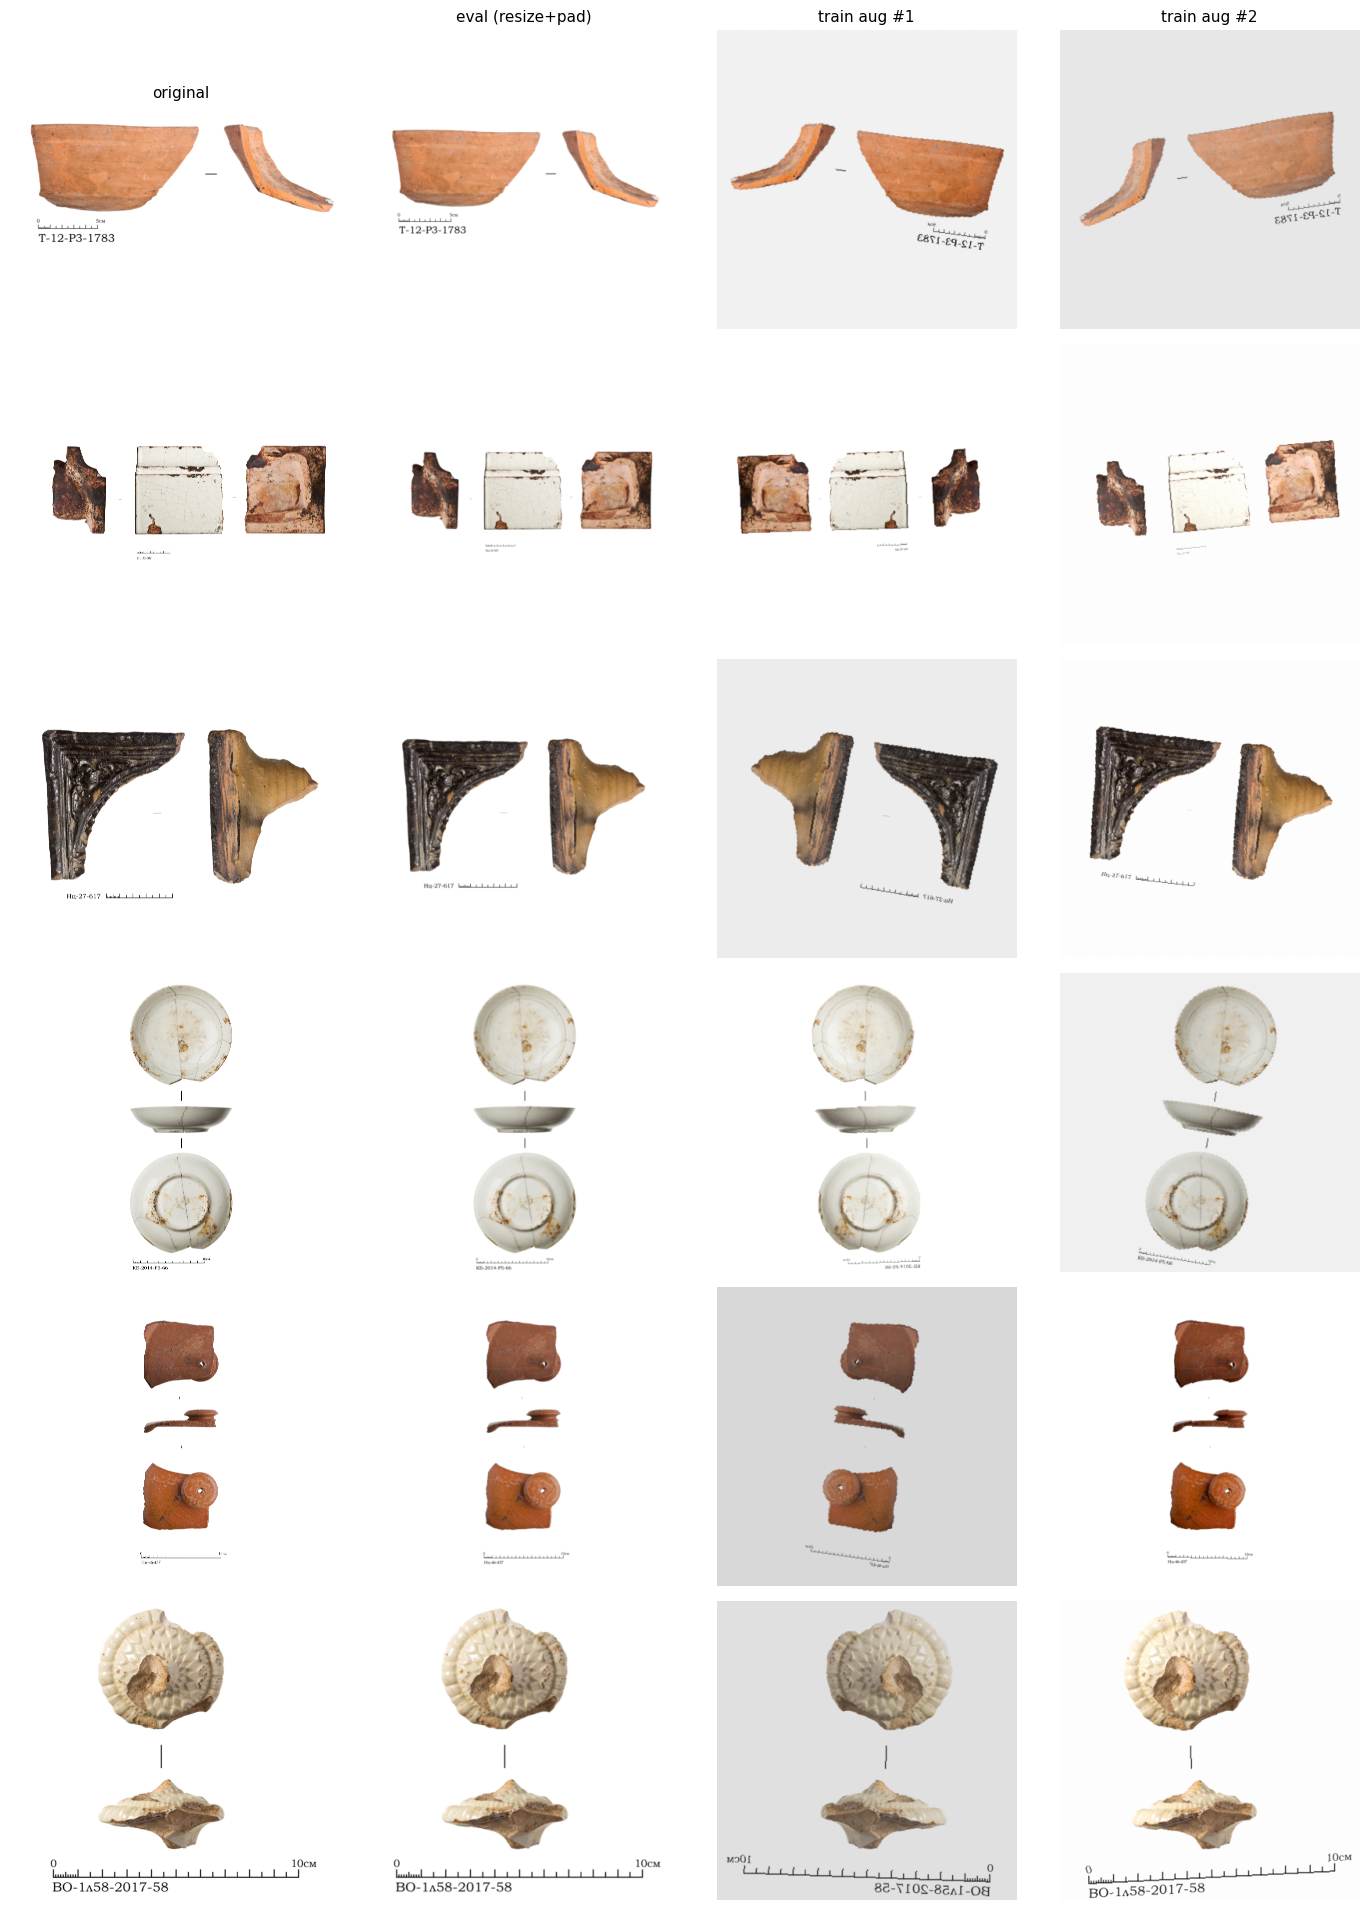

In [18]:
def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def show_augmentation_examples(df: pd.DataFrame, n: int = 6) -> None:
    """Show n images in 4 columns: original | eval | train aug #1 | train aug #2."""
    sample = df.sample(n, random_state=SEED)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    if n == 1:
        axes = axes[None, :]

    col_titles = ["original", "eval (resize+pad)", "train aug #1", "train aug #2"]

    for row, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(r["image_file"]).convert("RGB")

        axes[row, 0].imshow(img)
        eval_t = eval_transform(img)
        axes[row, 1].imshow(denormalize(eval_t).permute(1, 2, 0).numpy())
        for col in (2, 3):
            aug_t = train_transform(img)
            axes[row, col].imshow(denormalize(aug_t).permute(1, 2, 0).numpy())

        for col in range(4):
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=11)

        axes[row, 0].set_ylabel(r["code"], fontsize=8, rotation=0, labelpad=40)

    plt.tight_layout()
    plt.savefig("artifacts/figures/augmentations.png", dpi=100, bbox_inches="tight")
    plt.show()

show_augmentation_examples(df, n=6)


# Dataset и Dataloader

In [39]:
from typing import Callable, Dict, Tuple, Any
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

ALWAYS_PRESENT_FIELDS = ("name_norm", "fragm_norm", "material_norm")
MASKABLE_FIELDS = ("part_norm",)

class SIMILISDataset(Dataset):
    """Multi-task dataset for SIMILIS artifacts.

    Each item returns:
        image:    FloatTensor [3, H, W], ImageNet-normalized
        targets:  dict[str, LongTensor scalar] — class index per field
        mask:     dict[str, FloatTensor scalar] — 1.0 if label valid, else 0.0
        meta:     dict[str, str] — code, image_file, group_key for error analysis

    The dataset operates on a single split (train/val/test) — pass `df[df.split == "train"]`.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        transform: Callable[[Image.Image], torch.Tensor],
        target_fields: Tuple[str, ...] = tuple(TARGET_FIELDS),
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_fields = target_fields
        self._broken: list[str] = []

        required = {"image_file", "code", "group_key", "part_is_missing"} | {
            f"{f}_idx" for f in target_fields
        }
        missing = required - set(self.df.columns)
        if missing:
            raise ValueError(f"df is missing required columns: {missing}")

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[
        torch.Tensor,
        Dict[str, torch.Tensor],
        Dict[str, torch.Tensor],
        Dict[str, Any],
    ]:
        row = self.df.iloc[idx]

        try:
            img = Image.open(row["image_file"]).convert("RGB")
            image = self.transform(img)
            broken = False
        except Exception as e:
            self._broken.append(f"{row['code']}: {e}")
            dummy = Image.new("RGB", (256, 256), (PAD_FILL, PAD_FILL, PAD_FILL))
            image = self.transform(dummy)
            broken = True

        targets: Dict[str, torch.Tensor] = {}
        mask: Dict[str, torch.Tensor] = {}

        for field in self.target_fields:
            raw_idx = row[f"{field}_idx"]
            if pd.isna(raw_idx):
                targets[field] = torch.tensor(0, dtype=torch.long)
                mask[field] = torch.tensor(0.0, dtype=torch.float32)
            else:
                targets[field] = torch.tensor(int(raw_idx), dtype=torch.long)
                if field in MASKABLE_FIELDS and bool(row["part_is_missing"]):
                    mask[field] = torch.tensor(0.0, dtype=torch.float32)
                else:
                    mask[field] = torch.tensor(0.0 if broken else 1.0,
                                               dtype=torch.float32)
        if broken:
            for field in self.target_fields:
                mask[field] = torch.tensor(0.0, dtype=torch.float32)

        meta = {
            "code": str(row["code"]),
            "image_file": str(row["image_file"]),
            "group_key": str(row["group_key"]),
        }
        return image, targets, mask, meta

def build_dataloaders(
    df: pd.DataFrame,
    train_transform: Callable,
    eval_transform: Callable,
    batch_size: int = 32,
    num_workers: int = 0,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Build (train_loader, val_loader, test_loader) from a single prepared df.

    Train uses augmentations + shuffle + drop_last; val/test are deterministic.
    """
    train_ds = SIMILISDataset(df[df["split"] == "train"], train_transform)
    val_ds = SIMILISDataset(df[df["split"] == "val"], eval_transform)
    test_ds = SIMILISDataset(df[df["split"] == "test"], eval_transform)

    common = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
    )
    train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **common)

    print(f" train: {len(train_ds):4d} samples, {len(train_loader):3d} batches")
    print(f" val:   {len(val_ds):4d} samples, {len(val_loader):3d} batches")
    print(f" test:  {len(test_ds):4d} samples, {len(test_loader):3d} batches")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders(
    df, train_transform, eval_transform, batch_size=32, num_workers=0
)


 train:  774 samples,  24 batches
 val:    210 samples,   7 batches
 test:   183 samples,   6 batches


In [20]:
images, targets, mask, meta = next(iter(train_loader))

print("=== Shapes & dtypes ===")
print(f"images: {tuple(images.shape)}  dtype={images.dtype}")
for f in TARGET_FIELDS:
    print(f"  targets[{f}]: shape={tuple(targets[f].shape)} "
          f"dtype={targets[f].dtype}  "
          f"mask sum={mask[f].sum().item():.0f}/{len(mask[f])}")

print("\n=== Image value range (post-Normalize) ===")
print(f"  min={images.min():.2f}  max={images.max():.2f}  mean={images.mean():.2f}")
assert images.dtype == torch.float32
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert -3.0 < images.min() < images.max() < 3.0, "Normalize range looks off"

print("\n=== Class index ranges per field ===")
for f in TARGET_FIELDS:
    n_classes = len(label_encoders[f])
    t = targets[f]
    assert t.min() >= 0 and t.max() < n_classes, f"OOB index for {f}"
    print(f"  {f}: idx in [{t.min().item()}, {t.max().item()}]  "
          f"(n_classes={n_classes})")

# Mask correctness check on a known masked example
masked_rows = df[(df["split"] == "train") & (df["part_is_missing"])].head(3)
if len(masked_rows):
    ds = train_loader.dataset
    pos_in_ds = ds.df.index[ds.df["code"] == masked_rows.iloc[0]["code"]]
    if len(pos_in_ds):
        _, t, m, _ = ds[int(pos_in_ds[0])]
        print(f"\n=== Mask check on part_is_missing=True example ===")
        print(f"  code={masked_rows.iloc[0]['code']}")
        print(f"  mask[part_norm]={m['part_norm'].item()} (expected 0.0)")
        for f in ALWAYS_PRESENT_FIELDS:
            print(f"  mask[{f}]={m[f].item()} (expected 1.0)")
        assert m["part_norm"].item() == 0.0
        for f in ALWAYS_PRESENT_FIELDS:
            assert m[f].item() == 1.0

print(f"\n Broken images so far: {len(train_loader.dataset._broken)}")
print(" All sanity checks passed")


=== Shapes & dtypes ===
images: (32, 3, 384, 384)  dtype=torch.float32
  targets[name_norm]: shape=(32,) dtype=torch.int64  mask sum=32/32
  targets[fragm_norm]: shape=(32,) dtype=torch.int64  mask sum=32/32
  targets[material_norm]: shape=(32,) dtype=torch.int64  mask sum=32/32
  targets[part_norm]: shape=(32,) dtype=torch.int64  mask sum=19/32

=== Image value range (post-Normalize) ===
  min=-2.12  max=2.64  mean=1.94

=== Class index ranges per field ===
  name_norm: idx in [0, 6]  (n_classes=7)
  fragm_norm: idx in [0, 1]  (n_classes=2)
  material_norm: idx in [1, 4]  (n_classes=5)
  part_norm: idx in [0, 9]  (n_classes=11)

=== Mask check on part_is_missing=True example ===
  code=М102-2012-1-0494
  mask[part_norm]=0.0 (expected 0.0)
  mask[name_norm]=1.0 (expected 1.0)
  mask[fragm_norm]=1.0 (expected 1.0)
  mask[material_norm]=1.0 (expected 1.0)

 Broken images so far: 0
 All sanity checks passed


In [21]:
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    job_type="sanity_check",
    name="task9_dataloader_check",
    config={
        "image_size": IMAGE_SIZE,
        "pad_fill": PAD_FILL,
        "batch_size": 32,
        "num_workers": 2,
        "target_fields": list(TARGET_FIELDS),
        "n_classes": {f: len(label_encoders[f]) for f in TARGET_FIELDS},
        "seed": SEED,
    },
    tags=["part2", "task9", "sanity"],
)

wandb.summary["split/train"] = int((df["split"] == "train").sum())
wandb.summary["split/val"] = int((df["split"] == "val").sum())
wandb.summary["split/test"] = int((df["split"] == "test").sum())
wandb.summary["broken_images"] = len(train_loader.dataset._broken)

wandb.summary["image/min"] = float(images.min())
wandb.summary["image/max"] = float(images.max())
wandb.summary["image/mean"] = float(images.mean())
wandb.summary["image/std"] = float(images.std())

dist_rows = []
for f in TARGET_FIELDS:
    t = targets[f]
    m = mask[f]
    for cls_idx in range(len(label_encoders[f])):
        cnt = int((t == cls_idx).sum())
        if cnt:
            dist_rows.append([f, label_decoders[f][cls_idx], cnt])
    wandb.summary[f"mask_coverage/{f}"] = float(m.mean())

dist_table = wandb.Table(
    columns=["field", "class", "count_in_batch"], data=dist_rows
)
wandb.log({"batch/label_distribution": dist_table})

def batch_to_wandb_images(images, targets, mask, n=8):
    n = min(n, images.shape[0])
    out = []
    for i in range(n):
        img_np = (denormalize(images[i]).permute(1, 2, 0).numpy() * 255).astype("uint8")
        caption_parts = []
        for f in TARGET_FIELDS:
            idx = targets[f][i].item()
            label = label_decoders[f].get(idx, "?")
            tag = "" if mask[f][i].item() == 1.0 else "*"
            caption_parts.append(f"{f.replace('_norm','')}={label}{tag}")
        out.append(wandb.Image(img_np, caption=" | ".join(caption_parts)))
    return out

wandb.log({"batch/samples": batch_to_wandb_images(images, targets, mask, n=8)})

if os.path.exists("artifacts/figures/augmentations.png"):
    wandb.log({
        "augmentations/before_after": wandb.Image("artifacts/figures/augmentations.png")
    })

run.finish()
print(f" Sanity check logged to W&B: {run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: rixie (rixie-central-university-moscow) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


broken_images,0
image/max,2.64
image/mean,1.94193
image/min,-2.1179
image/std,0.8287
mask_coverage/fragm_norm,1
mask_coverage/material_norm,1
mask_coverage/name_norm,1
mask_coverage/part_norm,0.59375
split/test,183
+2,...


 Sanity check logged to W&B: https://wandb.ai/rixie-central-university-moscow/similis-baseline/runs/qjk9ykqn


Вот так выглядит вандб если что

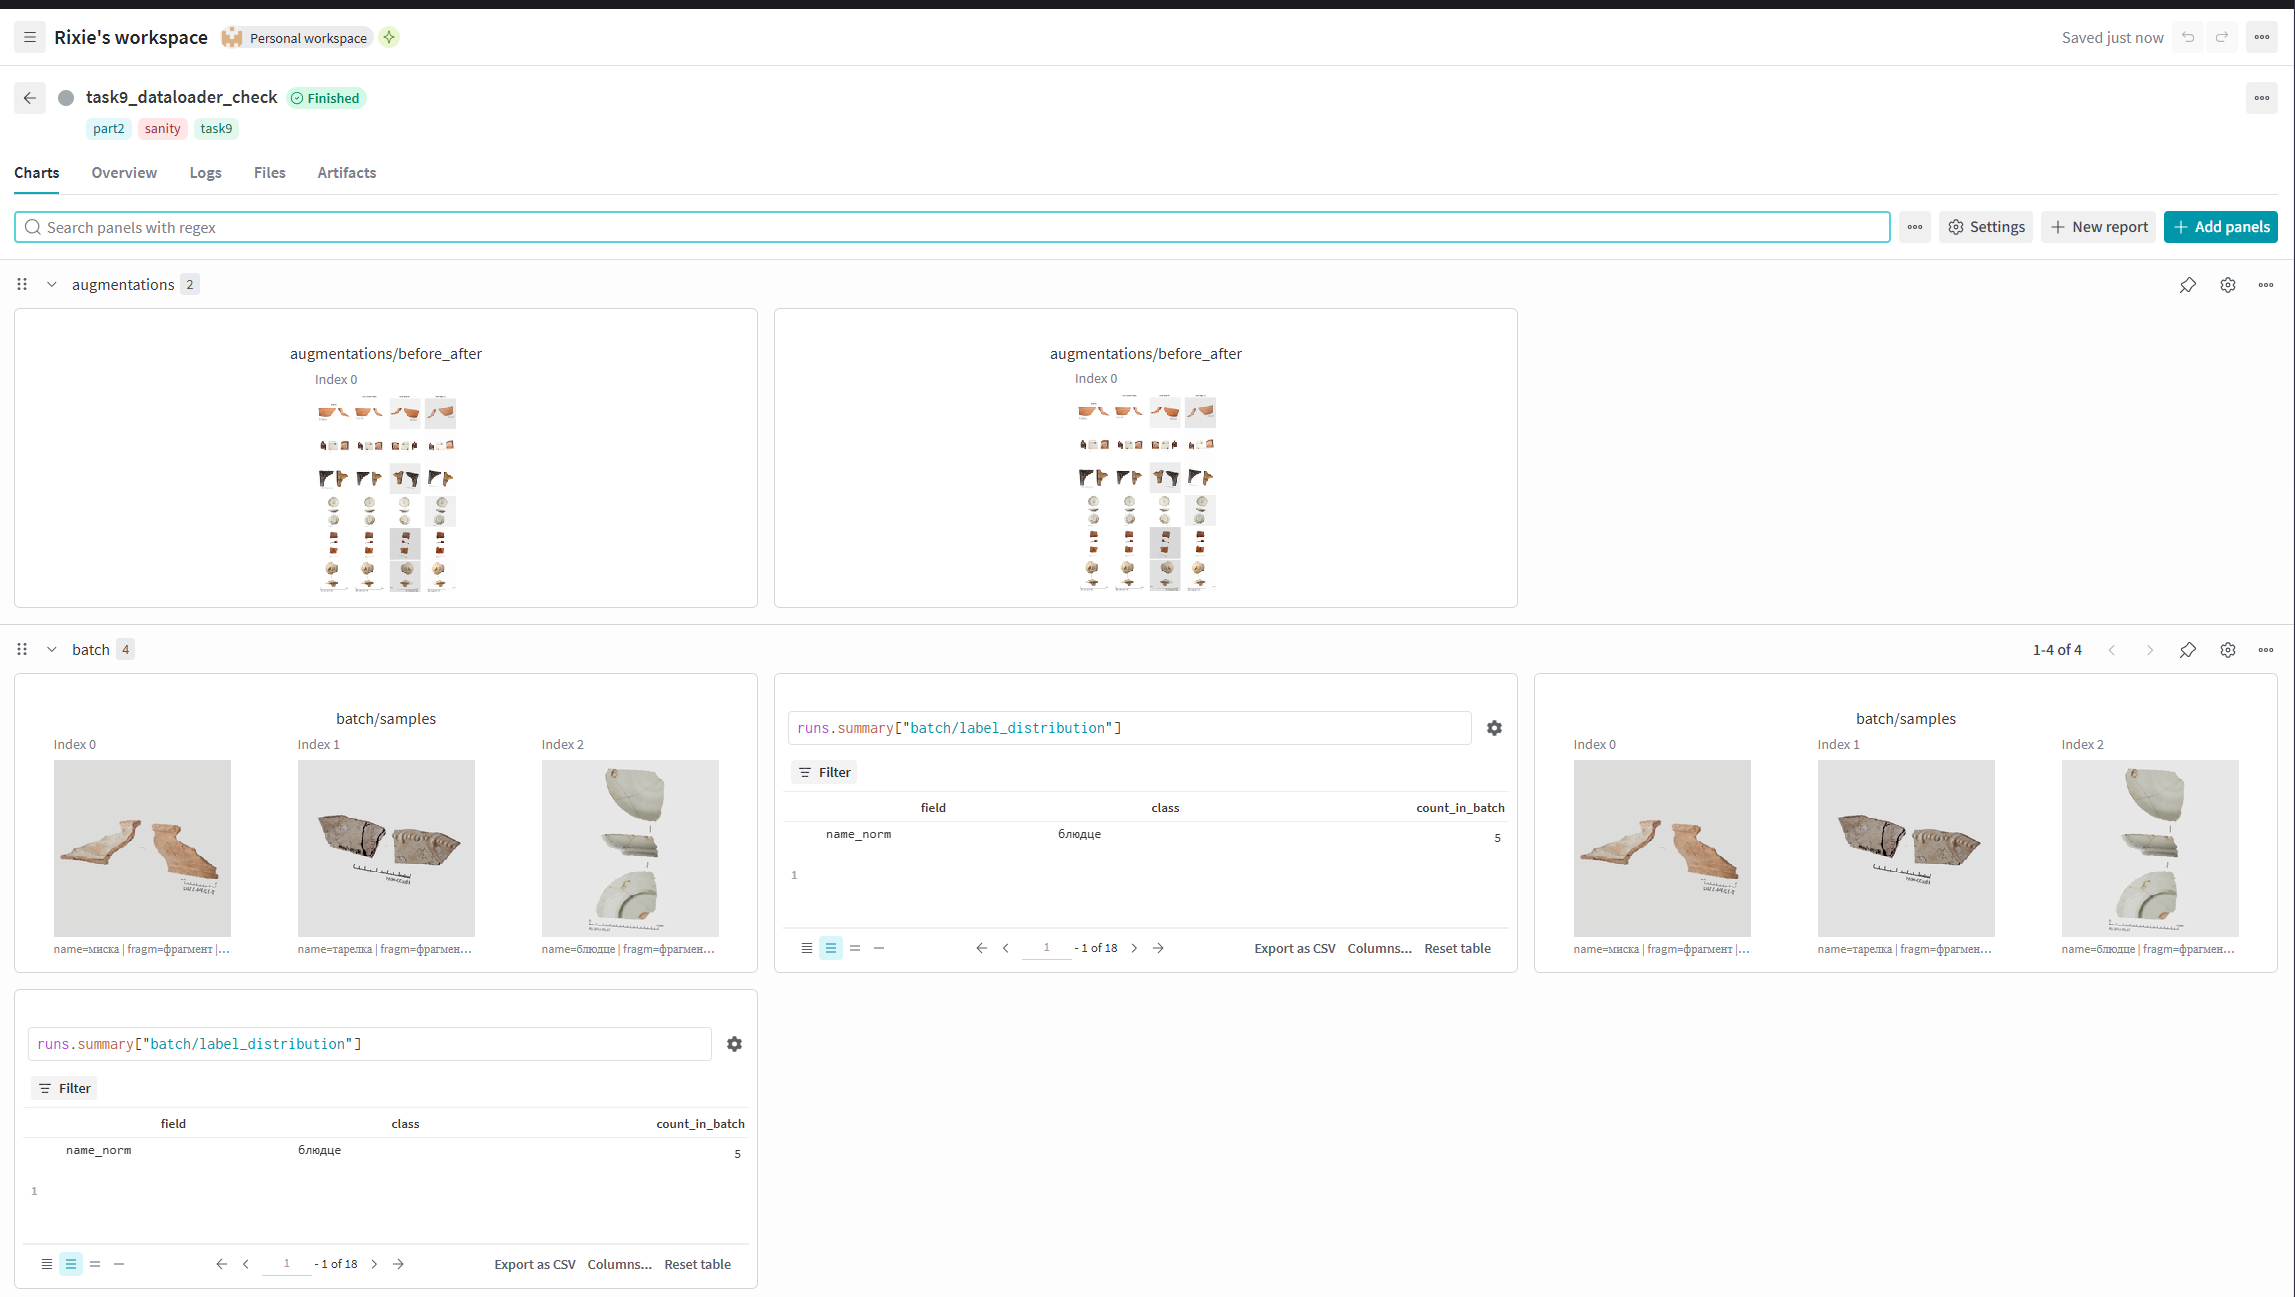

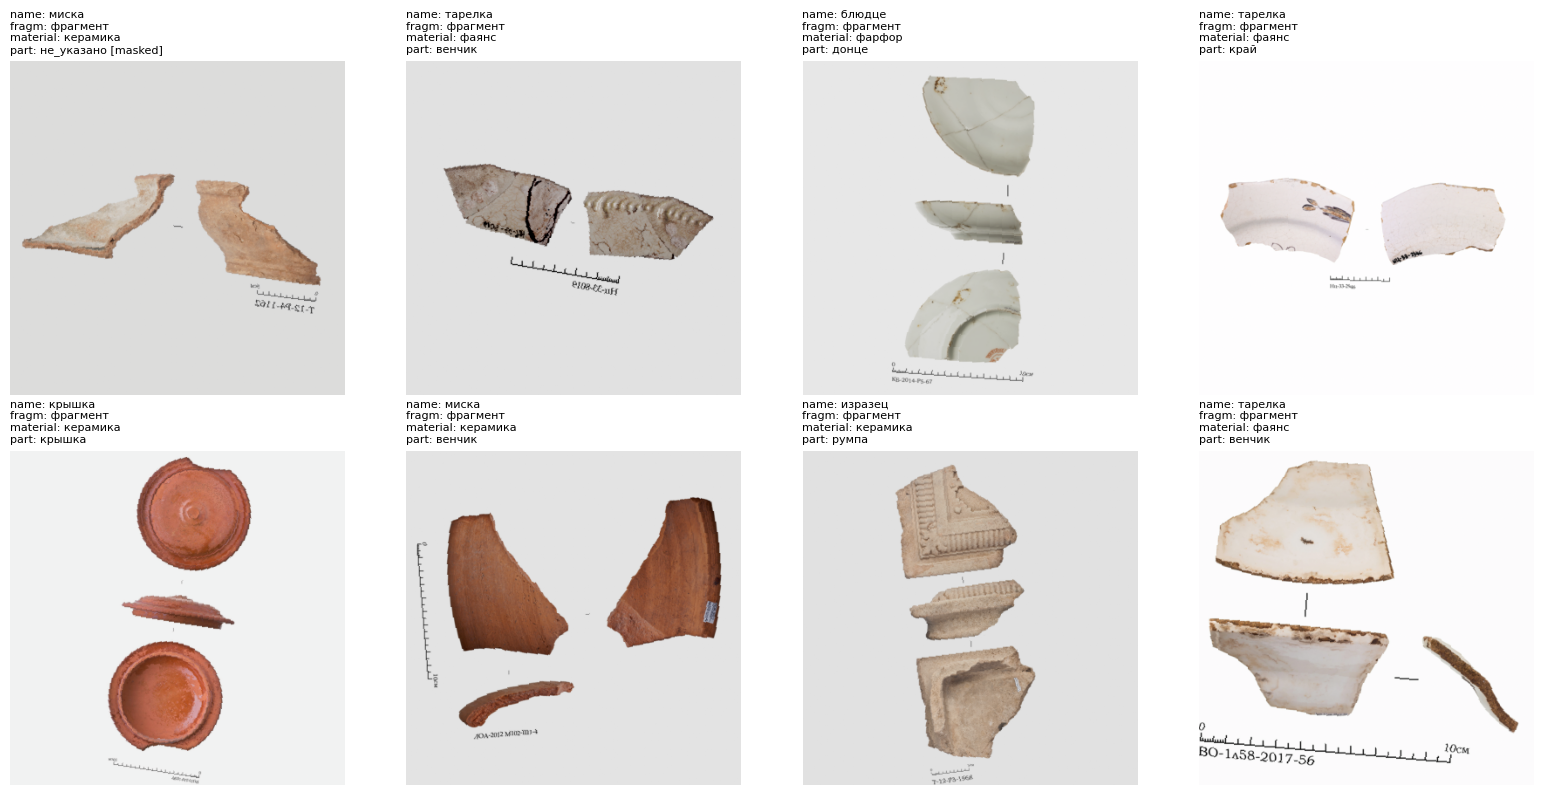

In [22]:
def show_batch(images: torch.Tensor, targets: dict, mask: dict, n: int = 8) -> None:
    n = min(n, images.shape[0])
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    for i in range(n):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis("off")

        lines = []
        for f in TARGET_FIELDS:
            idx = targets[f][i].item()
            label = label_decoders[f].get(idx, "?")
            tag = "" if mask[f][i].item() == 1.0 else " [masked]"
            short = f.replace("_norm", "")
            lines.append(f"{short}: {label}{tag}")
        axes[i].set_title("\n".join(lines), fontsize=8, loc="left")

    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig("artifacts/figures/batch_sample.png", dpi=100, bbox_inches="tight")
    plt.show()

show_batch(images, targets, mask, n=8)


# Модель

In [23]:
!pip install -q timm


In [24]:
from typing import Dict, List
import torch
import torch.nn as nn
import timm

class SIMILISMultiTask(nn.Module):
    """Shared ConvNeXt-Tiny backbone + independent classification head per field.

    Args:
        n_classes: mapping field_name -> number of classes.
        backbone_name: any timm model with global_pool='avg'. Default: convnext_tiny.
        pretrained: load ImageNet-22k weights.
        drop_rate: dropout before heads (0.0 = none).

    Forward:
        x: FloatTensor [B, 3, H, W]
        returns: dict[field_name -> FloatTensor [B, n_classes_field]] (raw logits)
    """

    def __init__(
        self,
        n_classes: Dict[str, int],
        backbone_name: str = "convnext_tiny.fb_in22k_ft_in1k",
        pretrained: bool = True,
        drop_rate: float = 0.1,
    ) -> None:
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,     # strip timm's own classifier
            global_pool="avg", # return pooled [B, feat_dim]
            drop_rate=0.0,     # applied manually below
        )
        self.feat_dim = self.backbone.num_features  # 768 for convnext_tiny

        self.dropout = nn.Dropout(drop_rate)
        self.heads = nn.ModuleDict(
            {field: nn.Linear(self.feat_dim, n) for field, n in n_classes.items()}
        )
        self._field_order: List[str] = list(n_classes.keys())

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        feats = self.backbone(x)           # [B, 768]
        feats = self.dropout(feats)
        return {f: self.heads[f](feats) for f in self._field_order}

    # -------- utilities --------

    def count_parameters(self) -> Dict[str, int]:
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"total": total, "trainable": trainable, "frozen": total - trainable}

    def freeze_backbone_stages(self, unfreeze_from_stage: int = 3) -> None:
        """Freeze ConvNeXt stages [0, unfreeze_from_stage), train the rest.

        ConvNeXt in timm exposes `.stages` as nn.Sequential of 4 stages (0..3).
        Stem is always frozen here.
        """
        # Stem
        for p in self.backbone.stem.parameters():
            p.requires_grad = False
        # Stages
        for i, stage in enumerate(self.backbone.stages):
            train = i >= unfreeze_from_stage
            for p in stage.parameters():
                p.requires_grad = train
        # norm_pre (if exists) stays trainable with the last stage
        if hasattr(self.backbone, "norm_pre"):
            for p in self.backbone.norm_pre.parameters():
                p.requires_grad = True

    def get_param_groups(
        self, lr_backbone: float = 3e-5, lr_heads: float = 3e-4, weight_decay: float = 1e-4
    ) -> List[dict]:
        """Two param groups for AdamW: trainable backbone params + heads."""
        backbone_params = [p for p in self.backbone.parameters() if p.requires_grad]
        head_params = list(self.heads.parameters())
        return [
            {"params": backbone_params, "lr": lr_backbone, "weight_decay": weight_decay},
            {"params": head_params,     "lr": lr_heads,    "weight_decay": weight_decay},
        ]

# --- instantiate ---
N_CLASSES = {f: len(label_encoders[f]) for f in TARGET_FIELDS}
print(f"N_CLASSES = {N_CLASSES}")

model = SIMILISMultiTask(n_classes=N_CLASSES, pretrained=True, drop_rate=0.1).to(DEVICE)

# Report BEFORE freezing
params_full = model.count_parameters()
print(f"\nFull model: {params_full['total']/1e6:.2f}M total, "
      f"{params_full['trainable']/1e6:.2f}M trainable")

# Apply partial-finetune freezing (stage 3 + heads)
model.freeze_backbone_stages(unfreeze_from_stage=3)
params_frozen = model.count_parameters()
print(f"After freeze: {params_frozen['trainable']/1e6:.2f}M trainable "
      f"({100*params_frozen['trainable']/params_frozen['total']:.1f}% of total)")
print(f"  frozen: {params_frozen['frozen']/1e6:.2f}M")


N_CLASSES = {'name_norm': 7, 'fragm_norm': 2, 'material_norm': 5, 'part_norm': 11}


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Full model: 27.84M total, 27.84M trainable
After freeze: 15.49M trainable (55.6% of total)
  frozen: 12.35M


In [25]:
model.eval()
with torch.no_grad():
    images_cuda = images.to(DEVICE)       # `images` from task 9 sanity check batch
    logits = model(images_cuda)

print("Output shapes (raw logits, pre-softmax):")
for f in TARGET_FIELDS:
    logit = logits[f]
    expected = (images.shape[0], N_CLASSES[f])
    assert logit.shape == expected, f"{f}: got {logit.shape}, expected {expected}"
    print(f"  {f}: {tuple(logit.shape)}  "
          f"range=[{logit.min().item():+.2f}, {logit.max().item():+.2f}]")

# Quick predicted-class sanity
print("\nPredicted classes on this untrained batch (first 4 samples):")
for i in range(4):
    parts = []
    for f in TARGET_FIELDS:
        pred_idx = logits[f][i].argmax().item()
        parts.append(f"{f.replace('_norm','')}={label_decoders[f][pred_idx]}")
    print(f"  [{i}] " + " | ".join(parts))

print("\n Forward pass works")


Output shapes (raw logits, pre-softmax):
  name_norm: (32, 7)  range=[-0.63, +0.89]
  fragm_norm: (32, 2)  range=[-0.88, +0.06]
  material_norm: (32, 5)  range=[-0.36, +0.80]
  part_norm: (32, 11)  range=[-0.76, +0.78]

Predicted classes on this untrained batch (first 4 samples):
  [0] name=блюдце | fragm=целый | material=стекло | part=румпа
  [1] name=тарелка | fragm=целый | material=керамика | part=другое
  [2] name=блюдце | fragm=целый | material=стекло | part=другое
  [3] name=блюдце | fragm=целый | material=керамика | part=другое

 Forward pass works


In [26]:
pass  # config in training run


# Loss + Tiny Overfit

In [27]:
from typing import Dict, Tuple
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedMultiTaskLoss(nn.Module):
    """Per-field CrossEntropy with per-sample masking.

    For each field:
        loss_f = sum_i mask_i * CE(logits_i, target_i) / max(1, sum_i mask_i)

    Total loss is the sum over fields. Per-field losses are also returned
    for logging.
    """

    def __init__(self, field_names: Tuple[str, ...]) -> None:
        super().__init__()
        self.field_names = tuple(field_names)
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(
        self,
        logits: Dict[str, torch.Tensor],
        targets: Dict[str, torch.Tensor],
        mask: Dict[str, torch.Tensor],
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        per_field: Dict[str, torch.Tensor] = {}
        total = torch.zeros((), device=next(iter(logits.values())).device)
        for f in self.field_names:
            ce_per_sample = self.ce(logits[f], targets[f])   # [B]
            m = mask[f].to(ce_per_sample.device)             # [B]
            denom = m.sum().clamp(min=1.0)
            loss_f = (ce_per_sample * m).sum() / denom
            per_field[f] = loss_f
            total = total + loss_f
        return total, per_field

criterion = MaskedMultiTaskLoss(field_names=TARGET_FIELDS)
print(f" Loss built for fields: {TARGET_FIELDS}")


 Loss built for fields: ['name_norm', 'fragm_norm', 'material_norm', 'part_norm']


In [28]:
model.train()

# Fresh batch from train_loader
images_b, targets_b, mask_b, _ = next(iter(train_loader))
images_b = images_b.to(DEVICE)
targets_b = {f: t.to(DEVICE) for f, t in targets_b.items()}
mask_b = {f: m.to(DEVICE) for f, m in mask_b.items()}

logits_b = model(images_b)
total_loss, per_field_loss = criterion(logits_b, targets_b, mask_b)

print("=== Loss values (one random batch, untrained model) ===")
print(f"  total: {total_loss.item():.4f}")
for f in TARGET_FIELDS:
    n_c = N_CLASSES[f]
    expected_random = float(torch.log(torch.tensor(n_c)))  # ln(n_classes)
    print(f"  {f}: {per_field_loss[f].item():.4f}  "
          f"(random baseline ~ {expected_random:.2f})")

# --- Gradient check ---
total_loss.backward()

grad_heads = sum(p.grad.abs().sum().item()
                 for p in model.heads.parameters() if p.grad is not None)
grad_stage3 = sum(p.grad.abs().sum().item()
                  for p in model.backbone.stages[3].parameters() if p.grad is not None)
grad_stage0 = sum(
    (p.grad.abs().sum().item() if p.grad is not None else 0.0)
    for p in model.backbone.stages[0].parameters()
)

print("\n=== Gradient L1 sums ===")
print(f"  heads:            {grad_heads:.4f}  (expected > 0)")
print(f"  backbone stage 3: {grad_stage3:.4f}  (expected > 0)")
print(f"  backbone stage 0: {grad_stage0:.4f}  (expected = 0 — frozen)")

assert grad_heads > 0, "Heads have no gradient — loss disconnected from heads"
assert grad_stage3 > 0, "Stage 3 has no gradient — freeze is wrong"
assert grad_stage0 == 0, "Stage 0 got gradient — freeze is broken"

model.zero_grad()
print("\n Gradients flow correctly")


=== Loss values (one random batch, untrained model) ===
  total: 6.9237
  name_norm: 1.9569  (random baseline ~ 1.95)
  fragm_norm: 0.9206  (random baseline ~ 0.69)
  material_norm: 1.5618  (random baseline ~ 1.61)
  part_norm: 2.4843  (random baseline ~ 2.40)

=== Gradient L1 sums ===
  heads:            992.6700  (expected > 0)
  backbone stage 3: 8502.7383  (expected > 0)
  backbone stage 0: 0.0000  (expected = 0 — frozen)

 Gradients flow correctly


In [29]:
from torch.optim import AdamW

TINY_N = 48
TINY_BATCH = 16
TINY_EPOCHS = 20

tiny_df = df[df["split"] == "train"].sample(n=TINY_N, random_state=SEED).reset_index(drop=True)
tiny_ds = SIMILISDataset(tiny_df, eval_transform)
tiny_loader = DataLoader(
    tiny_ds, batch_size=TINY_BATCH, shuffle=True, drop_last=False,
    num_workers=0, pin_memory=True,
)

tiny_model = SIMILISMultiTask(n_classes=N_CLASSES, pretrained=True, drop_rate=0.0).to(DEVICE)
tiny_model.freeze_backbone_stages(unfreeze_from_stage=3)

optimizer = AdamW(
    tiny_model.get_param_groups(lr_backbone=3e-4, lr_heads=3e-3, weight_decay=0.0)
)
tiny_criterion = MaskedMultiTaskLoss(field_names=TARGET_FIELDS)

# --- W&B run ---
run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    job_type="tiny_overfit", name="task11_tiny_overfit",
    config={"n_samples": TINY_N, "batch_size": TINY_BATCH, "epochs": TINY_EPOCHS,
            "lr_heads": 3e-3, "lr_backbone": 3e-4, "dropout": 0.0, "aug": False},
    tags=["part2", "task11"],
)

history = []
for epoch in range(TINY_EPOCHS):
    tiny_model.train()
    epoch_loss, epoch_correct, epoch_seen = 0.0, {f: 0 for f in TARGET_FIELDS}, {f: 0 for f in TARGET_FIELDS}

    for images_b, targets_b, mask_b, _ in tiny_loader:
        images_b = images_b.to(DEVICE)
        targets_b = {f: t.to(DEVICE) for f, t in targets_b.items()}
        mask_b = {f: m.to(DEVICE) for f, m in mask_b.items()}

        logits_b = tiny_model(images_b)
        total, _ = tiny_criterion(logits_b, targets_b, mask_b)

        optimizer.zero_grad()
        total.backward()
        optimizer.step()

        epoch_loss += total.item() * images_b.size(0)
        for f in TARGET_FIELDS:
            pred = logits_b[f].argmax(dim=1)
            valid = mask_b[f].bool()
            epoch_correct[f] += (pred[valid] == targets_b[f][valid]).sum().item()
            epoch_seen[f] += valid.sum().item()

    mean_loss = epoch_loss / len(tiny_ds)
    accs = {f: epoch_correct[f] / max(1, epoch_seen[f]) for f in TARGET_FIELDS}
    history.append((epoch, mean_loss, accs))

    log = {"tiny/loss": mean_loss, "tiny/epoch": epoch}
    for f in TARGET_FIELDS:
        log[f"tiny/acc_{f}"] = accs[f]
    wandb.log(log, step=epoch)

    if epoch % 2 == 0 or epoch == TINY_EPOCHS - 1:
        acc_str = "  ".join(f"{f.replace('_norm','')}={accs[f]:.2f}" for f in TARGET_FIELDS)
        print(f"epoch {epoch:02d}  loss={mean_loss:.4f}  {acc_str}")

run.finish()

# --- Verdict ---
_, final_loss, final_accs = history[-1]
print("\n=== Tiny overfit verdict ===")
print(f"final loss: {final_loss:.4f}  (target < 0.10)")
for f in TARGET_FIELDS:
    status = "" if final_accs[f] >= 0.90 else "✗"
    print(f"  {status} {f}: acc={final_accs[f]:.3f}  (target ≥ 0.90)")


epoch 00  loss=5.9885  name=0.31  fragm=0.77  material=0.50  part=0.20
epoch 02  loss=2.8659  name=0.75  fragm=0.94  material=0.94  part=0.67
epoch 04  loss=0.6126  name=0.98  fragm=0.96  material=1.00  part=1.00
epoch 06  loss=0.0678  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 08  loss=0.0086  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 10  loss=0.0025  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 12  loss=0.0011  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 14  loss=0.0006  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 16  loss=0.0004  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 18  loss=0.0002  name=1.00  fragm=1.00  material=1.00  part=1.00
epoch 19  loss=0.0002  name=1.00  fragm=1.00  material=1.00  part=1.00


tiny/acc_fragm_norm,▁▄▆█▇▇██████████████
tiny/acc_material_norm,▁▄▇▇████████████████
tiny/acc_name_norm,▁▄▅▆████████████████
tiny/acc_part_norm,▁▃▅▇████████████████
tiny/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
tiny/loss,█▆▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
tiny/acc_fragm_norm,1
tiny/acc_material_norm,1
tiny/acc_name_norm,1
tiny/acc_part_norm,1
tiny/epoch,19



=== Tiny overfit verdict ===
final loss: 0.0002  (target < 0.10)
   name_norm: acc=1.000  (target ≥ 0.90)
   fragm_norm: acc=1.000  (target ≥ 0.90)
   material_norm: acc=1.000  (target ≥ 0.90)
   part_norm: acc=1.000  (target ≥ 0.90)


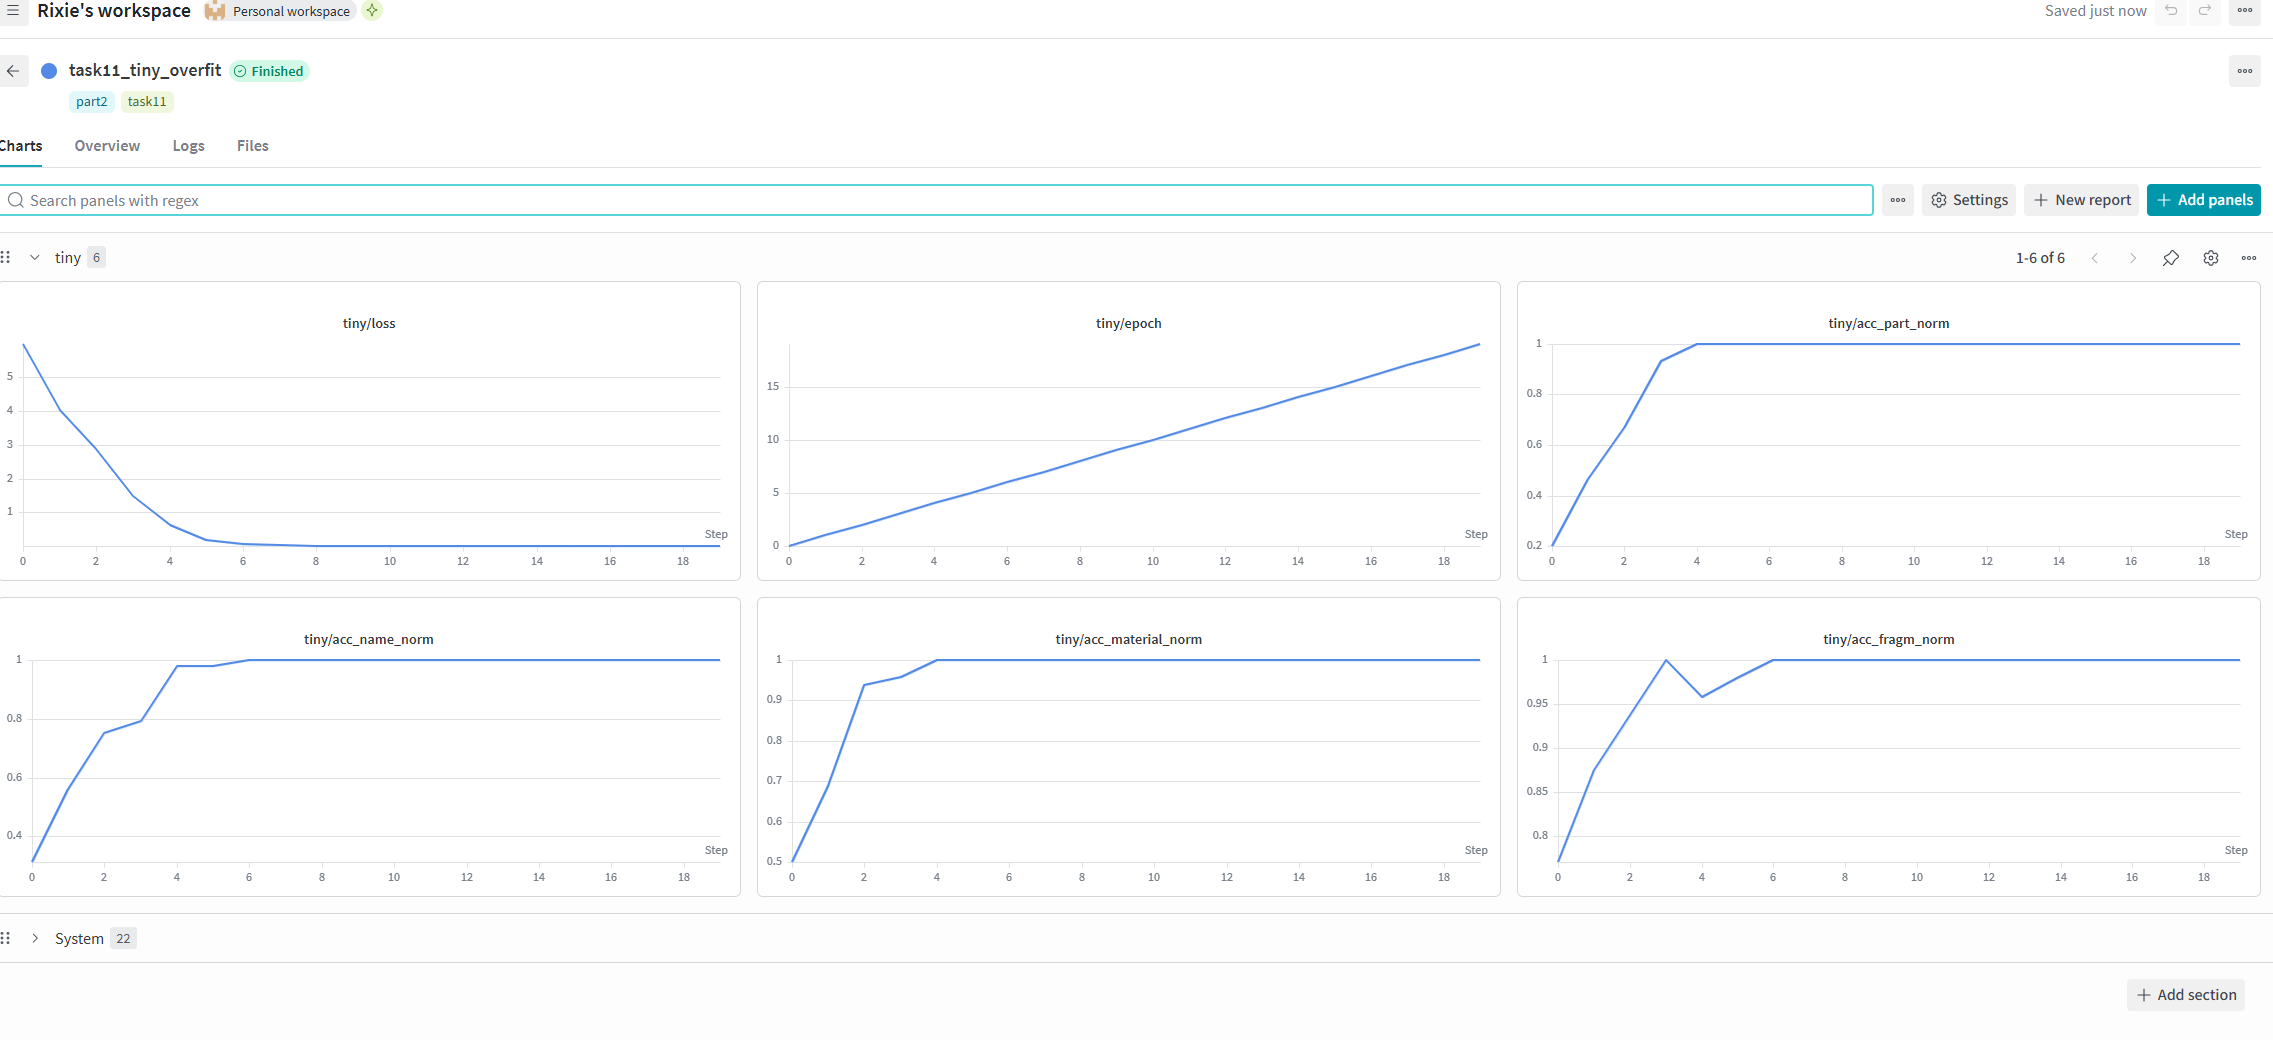

# Train-Eval loop + optimizer + scheduler

In [30]:
from sklearn.metrics import accuracy_score, f1_score
from collections import Counter

def compute_class_weights(df: pd.DataFrame, field: str, encoder: dict,
                          cap: float = 10.0) -> torch.Tensor:
    """Inverse-frequency weights, capped at `cap` to prevent gradient explosion."""
    counts = df[field + "_idx"].dropna().value_counts()
    n_total = counts.sum()
    n_classes = len(encoder)
    weights = torch.ones(n_classes, dtype=torch.float32)
    for label, idx in encoder.items():
        c = counts.get(label, 1)
        w = n_total / (n_classes * c)
        weights[idx] = min(w, cap)
    return weights

class WeightedMaskedMultiTaskLoss(nn.Module):
    """Per-field CE with class weights + per-sample masking."""

    def __init__(self, field_names: tuple, class_weights: Dict[str, torch.Tensor]) -> None:
        super().__init__()
        self.field_names = field_names
        self.criteria = {}
        for f in field_names:
            w = class_weights.get(f)
            self.criteria[f] = nn.CrossEntropyLoss(weight=w, reduction="none")

    def to(self, device):
        for f in self.field_names:
            self.criteria[f] = self.criteria[f].to(device)
        return self

    def forward(self, logits, targets, mask):
        per_field = {}
        total = torch.zeros((), device=next(iter(logits.values())).device)
        for f in self.field_names:
            ce = self.criteria[f](logits[f], targets[f])
            m = mask[f].to(ce.device)
            denom = m.sum().clamp(min=1.0)
            loss_f = (ce * m).sum() / denom
            per_field[f] = loss_f
            total = total + loss_f
        return total, per_field

# Build class weights from train split
train_df = df[df["split"] == "train"]
class_weights = {}
for f in TARGET_FIELDS:
    w = compute_class_weights(train_df, f, label_encoders[f], cap=10.0)
    class_weights[f] = w
    print(f"{f}: weights = {[f'{v:.2f}' for v in w.tolist()]}")

train_criterion = WeightedMaskedMultiTaskLoss(TARGET_FIELDS, class_weights).to(DEVICE)
val_criterion = MaskedMultiTaskLoss(field_names=TARGET_FIELDS)  # no weights for val
print("\n Weighted loss built")


name_norm: weights = ['10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00']
fragm_norm: weights = ['10.00', '10.00']
material_norm: weights = ['10.00', '10.00', '10.00', '10.00', '10.00']
part_norm: weights = ['10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00', '10.00']

 Weighted loss built


In [31]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

@torch.no_grad()
def evaluate(model, loader, criterion, device) -> dict:
    """Run eval, return {loss, per-field acc & macro_f1, mean_macro_f1}."""
    model.eval()
    all_preds = {f: [] for f in TARGET_FIELDS}
    all_targets = {f: [] for f in TARGET_FIELDS}
    all_masks = {f: [] for f in TARGET_FIELDS}
    total_loss, n = 0.0, 0

    for imgs, tgts, msk, _ in loader:
        imgs = imgs.to(device)
        tgts_d = {f: t.to(device) for f, t in tgts.items()}
        msk_d = {f: m.to(device) for f, m in msk.items()}

        logits = model(imgs)
        loss, _ = criterion(logits, tgts_d, msk_d)
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

        for f in TARGET_FIELDS:
            preds = logits[f].argmax(dim=1).cpu()
            all_preds[f].append(preds)
            all_targets[f].append(tgts[f])
            all_masks[f].append(msk[f])

    metrics = {"loss": total_loss / max(1, n)}
    f1s = []
    for f in TARGET_FIELDS:
        p = torch.cat(all_preds[f]).numpy()
        t = torch.cat(all_targets[f]).numpy()
        m = torch.cat(all_masks[f]).bool().numpy()
        p_valid, t_valid = p[m], t[m]
        acc = accuracy_score(t_valid, p_valid)
        mf1 = f1_score(t_valid, p_valid, average="macro", zero_division=0)
        metrics[f"acc_{f}"] = acc
        metrics[f"macro_f1_{f}"] = mf1
        f1s.append(mf1)
    metrics["mean_macro_f1"] = float(np.mean(f1s))
    return metrics

def train_one_epoch(model, loader, criterion, optimizer, device) -> dict:
    """Train one epoch, return {loss, per-field train acc}."""
    model.train()
    total_loss, n = 0.0, 0
    all_preds = {f: [] for f in TARGET_FIELDS}
    all_targets = {f: [] for f in TARGET_FIELDS}
    all_masks = {f: [] for f in TARGET_FIELDS}

    for imgs, tgts, msk, _ in loader:
        imgs = imgs.to(device)
        tgts_d = {f: t.to(device) for f, t in tgts.items()}
        msk_d = {f: m.to(device) for f, m in msk.items()}

        logits = model(imgs)
        loss, _ = criterion(logits, tgts_d, msk_d)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
        for f in TARGET_FIELDS:
            all_preds[f].append(logits[f].detach().argmax(dim=1).cpu())
            all_targets[f].append(tgts[f])
            all_masks[f].append(msk[f])

    metrics = {"loss": total_loss / max(1, n)}
    for f in TARGET_FIELDS:
        p = torch.cat(all_preds[f]).numpy()
        t = torch.cat(all_targets[f]).numpy()
        m = torch.cat(all_masks[f]).bool().numpy()
        metrics[f"acc_{f}"] = accuracy_score(t[m], p[m])
    return metrics

print(" train_one_epoch + evaluate defined")


 train_one_epoch + evaluate defined


In [32]:
import time

N_EPOCHS = 30
LR_BACKBONE = 3e-5
LR_HEADS = 3e-4
WEIGHT_DECAY = 1e-4

CKPT_DIR = "/content/drive/MyDrive/cu_data/similis_artifacts/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)


In [40]:
# Fresh model
model = SIMILISMultiTask(n_classes=N_CLASSES, pretrained=True, drop_rate=0.1).to(DEVICE)
model.freeze_backbone_stages(unfreeze_from_stage=3)

optimizer = AdamW(
    model.get_param_groups(LR_BACKBONE, LR_HEADS, WEIGHT_DECAY)
)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

# --- W&B init with full config ---
run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    job_type="train", name="baseline_30ep",
    config={
        "epochs": N_EPOCHS, "lr_backbone": LR_BACKBONE, "lr_heads": LR_HEADS,
        "weight_decay": WEIGHT_DECAY, "scheduler": "CosineAnnealingLR",
        "batch_size": 32, "image_size": IMAGE_SIZE, "pad_fill": PAD_FILL,
        "backbone": "convnext_tiny.fb_in22k_ft_in1k", "drop_rate": 0.1,
        "unfreeze_from_stage": 3, "class_weight_cap": 10.0,
        "n_classes": N_CLASSES, "seed": SEED,
        "train_samples": int((df["split"] == "train").sum()),
        "val_samples": int((df["split"] == "val").sum()),
        "test_samples": int((df["split"] == "test").sum()),
    },
    tags=["part2", "baseline"],
)

# --- Pre-training diagnostics ---
n_train_batches = len(train_loader)
n_val_batches = len(val_loader)
params = model.count_parameters()
best_metric = 0.0
t_start_total = time.time()

for epoch in range(N_EPOCHS):
    t_epoch = time.time()

    # ---- TRAIN ----
    model.train()
    running_loss = 0.0
    n_samples = 0
    train_preds = {f: [] for f in TARGET_FIELDS}
    train_targets = {f: [] for f in TARGET_FIELDS}
    train_masks = {f: [] for f in TARGET_FIELDS}

    for batch_idx, (imgs, tgts, msk, _) in enumerate(train_loader):
        imgs = imgs.to(DEVICE)
        tgts_d = {f: t.to(DEVICE) for f, t in tgts.items()}
        msk_d = {f: m.to(DEVICE) for f, m in msk.items()}

        logits = model(imgs)
        loss, per_field_loss = train_criterion(logits, tgts_d, msk_d)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        running_loss += loss.item() * bs
        n_samples += bs

        for f in TARGET_FIELDS:
            train_preds[f].append(logits[f].detach().argmax(1).cpu())
            train_targets[f].append(tgts[f])
            train_masks[f].append(msk[f])

        # --- First-epoch per-batch progress (confirms training started) ---
        if epoch == 0 and (batch_idx + 1) % 5 == 0:
            avg = running_loss / n_samples
            pfl = {f.replace("_norm", ""): per_field_loss[f].item()
                   for f in TARGET_FIELDS}
            pfl_str = "  ".join(f"{k}={v:.3f}" for k, v in pfl.items())
            print(f"  [ep 00 batch {batch_idx+1:3d}/{n_train_batches}]  "
                  f"loss={avg:.3f}  ({pfl_str})")

    # Train metrics
    train_loss = running_loss / max(1, n_samples)
    train_accs = {}
    for f in TARGET_FIELDS:
        p = torch.cat(train_preds[f]).numpy()
        t = torch.cat(train_targets[f]).numpy()
        m = torch.cat(train_masks[f]).bool().numpy()
        train_accs[f] = accuracy_score(t[m], p[m])

    # ---- EVAL ----
    val_m = evaluate(model, val_loader, val_criterion, DEVICE)

    lr_now = scheduler.get_last_lr()[0]
    scheduler.step()
    dt_epoch = time.time() - t_epoch

    # ---- W&B LOG (every epoch, detailed) ----
    log = {"epoch": epoch, "lr": lr_now, "epoch_time_s": dt_epoch}
    # train
    log["train/loss"] = train_loss
    for f in TARGET_FIELDS:
        log[f"train/acc_{f}"] = train_accs[f]
    # val
    log["val/loss"] = val_m["loss"]
    for f in TARGET_FIELDS:
        log[f"val/acc_{f}"] = val_m[f"acc_{f}"]
        log[f"val/macro_f1_{f}"] = val_m[f"macro_f1_{f}"]
    log["val/mean_macro_f1"] = val_m["mean_macro_f1"]
    # gap (overfitting monitor)
    log["gap/loss"] = train_loss - val_m["loss"]
    log["gap/acc_mean"] = (
        float(np.mean(list(train_accs.values())))
        - float(np.mean([val_m[f"acc_{f}"] for f in TARGET_FIELDS]))
    )
    wandb.log(log, step=epoch)

    # ---- CHECKPOINTING ----
    ckpt_payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_metric": max(best_metric, val_m["mean_macro_f1"]),
        "label_encoders": label_encoders,
        "label_decoders": {k: {int(kk): vv for kk, vv in v.items()}
                          for k, v in label_decoders.items()},
        "n_classes": N_CLASSES,
        "target_fields": TARGET_FIELDS,
        "confidence_thresholds": CONFIDENCE_THRESHOLDS,
        "image_size": IMAGE_SIZE,
    }
    torch.save(ckpt_payload, f"{CKPT_DIR}/last.pt")

    if val_m["mean_macro_f1"] > best_metric:
        best_metric = val_m["mean_macro_f1"]
        ckpt_payload["best_metric"] = best_metric
        torch.save(ckpt_payload, f"{CKPT_DIR}/best.pt")
        marker = " *"
    else:
        marker = ""

    # ---- CONSOLE (every epoch) ----
    eta_s = dt_epoch * (N_EPOCHS - epoch - 1)
    eta_m = eta_s / 60

    f1_parts = []
    for f in TARGET_FIELDS:
        short = f.replace("_norm", "")
        f1_parts.append(f"{short}={val_m[f'macro_f1_{f}']:.3f}")

    print(
        f"ep {epoch:02d}/{N_EPOCHS}  "
        f"t_loss={train_loss:.3f}  v_loss={val_m['loss']:.3f}  "
        f"v_mF1={val_m['mean_macro_f1']:.3f}  "
        f"[{' | '.join(f1_parts)}]  "
        f"lr={lr_now:.1e}  "
        f"{dt_epoch:.0f}s  ETA {eta_m:.0f}m"
        f"{marker}"
    )

# ---- FINAL SUMMARY ----
total_time = time.time() - t_start_total
print(f"done: best val mF1={best_metric:.4f}, ckpt {CKPT_DIR}/best.pt")
run.finish()


  [ep 00 batch   5/24]  loss=63.168  (name=18.987  fragm=4.422  material=12.759  part=22.220)
  [ep 00 batch  10/24]  loss=56.686  (name=16.614  fragm=0.629  material=12.456  part=19.456)


KeyboardInterrupt: 

Как видим, ячейка работает, т.к. она уже запускалась раньше, до конца ее прогонять не буду, подтверждением работоспособности будут логи, скриншоты и  графики в artifacts и в самом ноутбуке

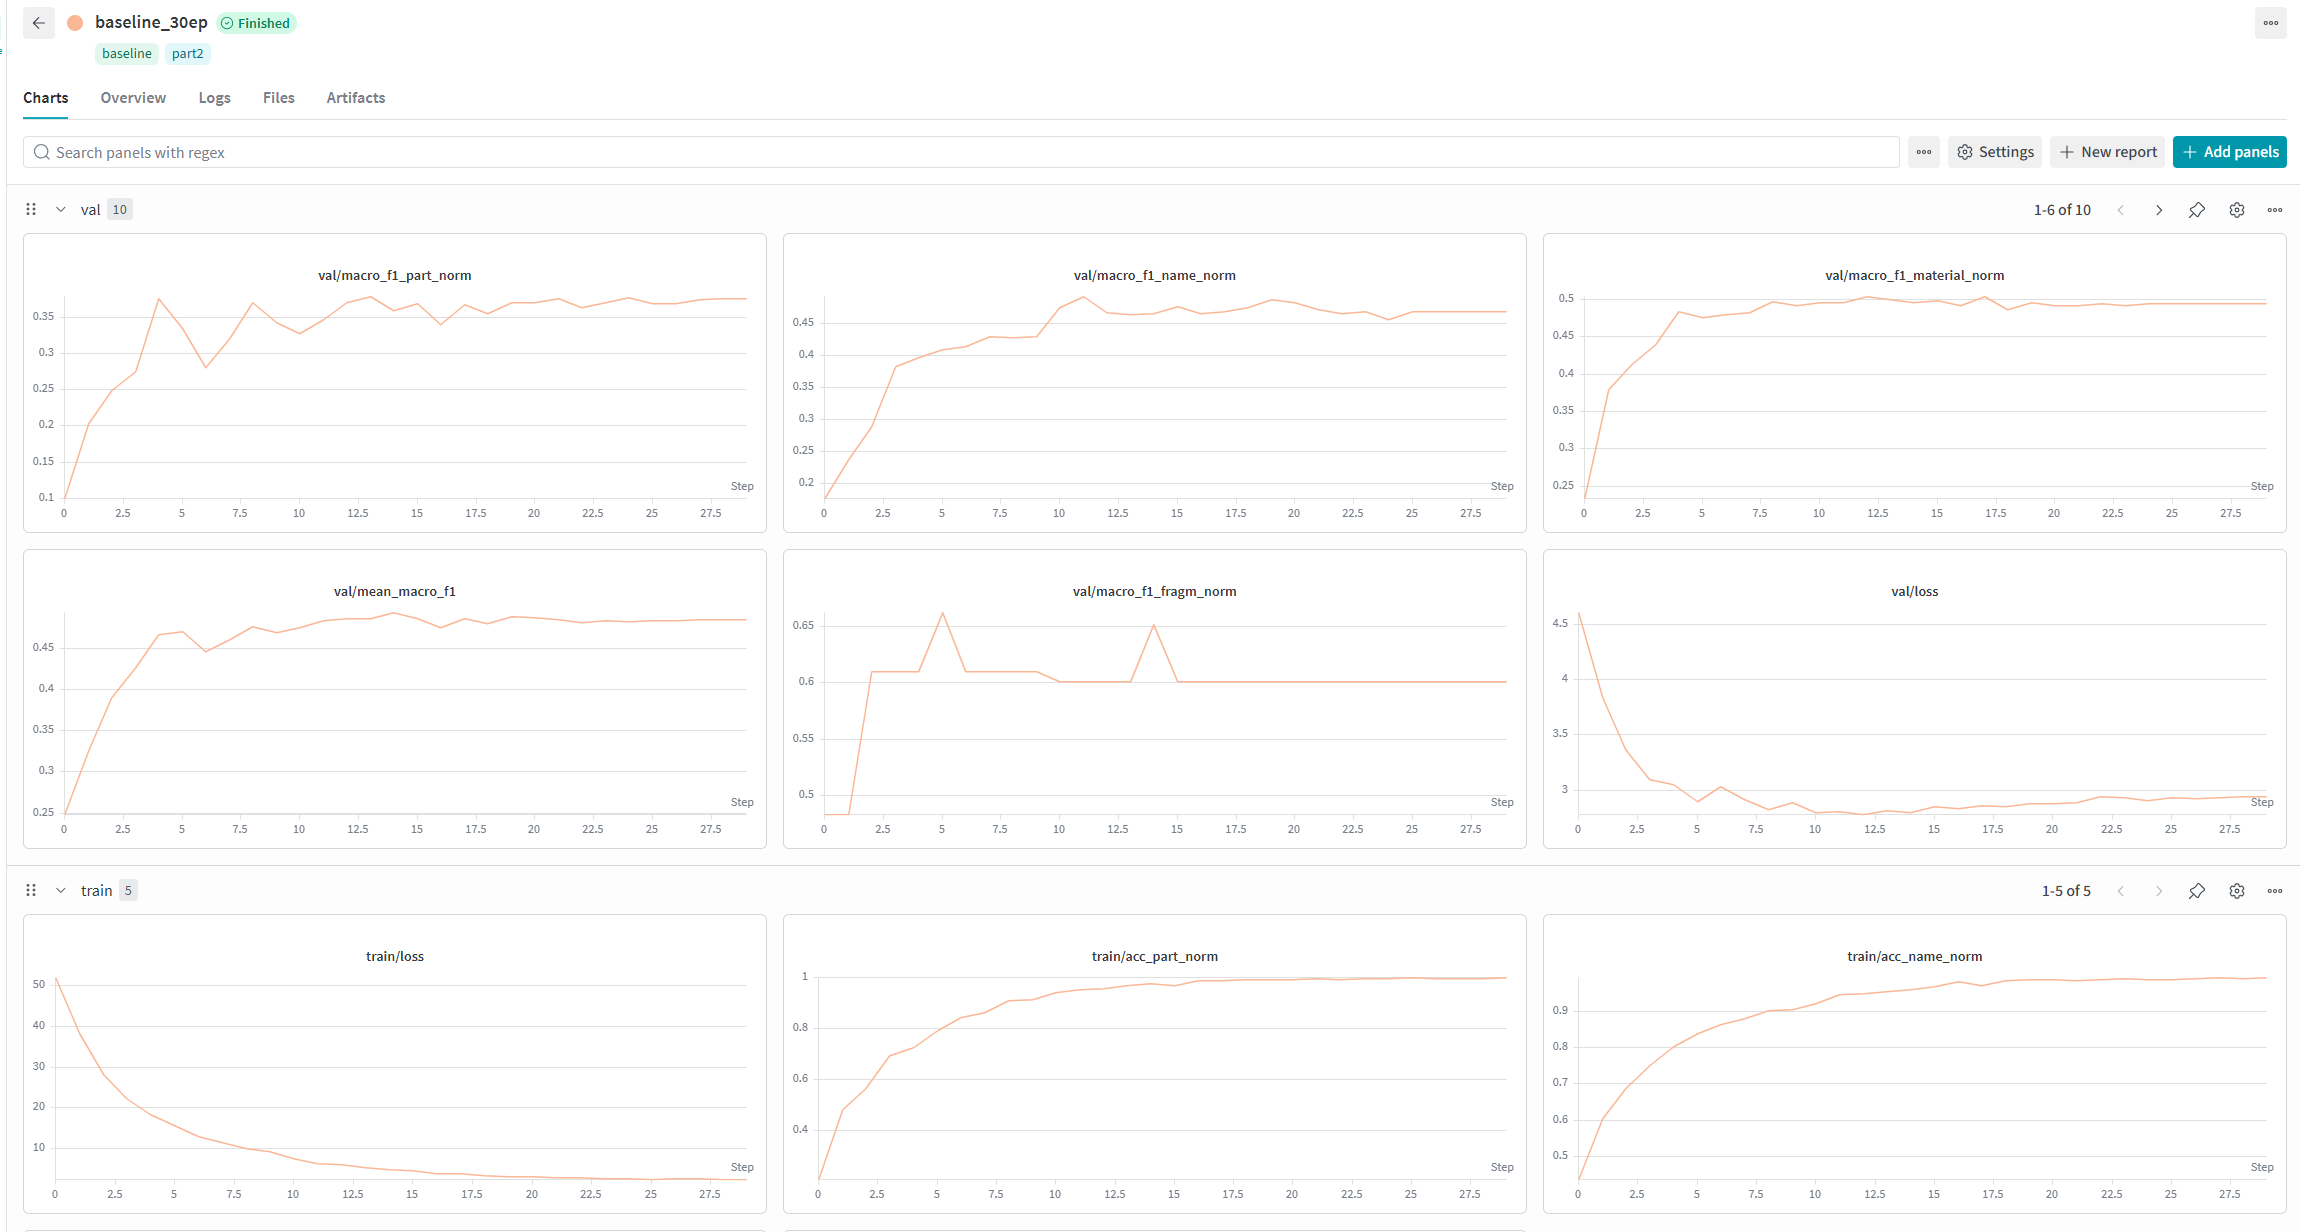

In [41]:
from typing import Optional

BASELINE_CKPT = f"{CKPT_DIR}/best.pt"

_baseline_cache: Optional[dict] = None

def get_baseline_metrics(
    ckpt_path: str = BASELINE_CKPT,
    loader: DataLoader = val_loader,
    force: bool = False,
) -> dict:
    """Load baseline checkpoint and evaluate on val. Cached after first call."""
    global _baseline_cache
    if _baseline_cache is not None and not force:
        return _baseline_cache

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    bl_model = SIMILISMultiTask(
        n_classes=ckpt["n_classes"], pretrained=False, drop_rate=0.0
    ).to(DEVICE)
    bl_model.load_state_dict(ckpt["model_state_dict"])
    bl_criterion = MaskedMultiTaskLoss(field_names=TARGET_FIELDS)

    metrics = evaluate(bl_model, loader, bl_criterion, DEVICE)
    metrics["_epoch"] = ckpt["epoch"]
    _baseline_cache = metrics
    print(f" Baseline loaded from epoch {ckpt['epoch']}, "
          f"mean_macro_f1={metrics['mean_macro_f1']:.4f}")
    return metrics

def compare_with_baseline(exp_metrics, exp_name="experiment", baseline_metrics=None):
    bl = baseline_metrics or get_baseline_metrics()
    rows = []
    for f in TARGET_FIELDS:
        for metric, key in [("macro_f1", f"macro_f1_{f}"), ("accuracy", f"acc_{f}")]:
            rows.append({
                "field": f.replace("_norm", ""),
                "metric": metric,
                "baseline": bl[key],
                exp_name: exp_metrics[key],
                "delta": exp_metrics[key] - bl[key],
            })
    rows.append({
        "field": "mean",
        "metric": "macro_f1",
        "baseline": bl["mean_macro_f1"],
        exp_name: exp_metrics["mean_macro_f1"],
        "delta": exp_metrics["mean_macro_f1"] - bl["mean_macro_f1"],
    })
    result = pd.DataFrame(rows)
    print(result.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return result

def log_ablation_to_wandb(
    exp_name: str,
    exp_metrics: dict,
    exp_config: dict,
    baseline_metrics: Optional[dict] = None,
) -> None:
    """Log ablation comparison as a W&B Table artifact."""
    bl = baseline_metrics or get_baseline_metrics()
    table_data = []
    for f in TARGET_FIELDS:
        key = f"macro_f1_{f}"
        table_data.append([
            f.replace("_norm", ""), "macro_f1",
            bl[key], exp_metrics[key], exp_metrics[key] - bl[key],
        ])
    table_data.append([
        "MEAN", "macro_f1",
        bl["mean_macro_f1"], exp_metrics["mean_macro_f1"],
        exp_metrics["mean_macro_f1"] - bl["mean_macro_f1"],
    ])

    table = wandb.Table(
        columns=["field", "metric", "baseline", exp_name, "delta"],
        data=table_data,
    )
    wandb.log({f"ablation/{exp_name}_vs_baseline": table})

print(" compare_with_baseline + log_ablation_to_wandb defined")


 compare_with_baseline + log_ablation_to_wandb defined


## Метрики на val


In [42]:
ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f" Loaded best.pt (epoch {ckpt['epoch']}, "
      f"best_metric={ckpt['best_metric']:.4f})")

model.eval()
val_preds = {f: [] for f in TARGET_FIELDS}
val_targets = {f: [] for f in TARGET_FIELDS}
val_masks = {f: [] for f in TARGET_FIELDS}
val_confs = {f: [] for f in TARGET_FIELDS}
val_codes = []
val_files = []

with torch.no_grad():
    for imgs, tgts, msk, meta in val_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        for f in TARGET_FIELDS:
            probs = torch.softmax(logits[f], dim=1)
            pred = probs.argmax(dim=1)
            conf = probs.max(dim=1).values
            val_preds[f].append(pred.cpu())
            val_confs[f].append(conf.cpu())
            val_targets[f].append(tgts[f])
            val_masks[f].append(msk[f])
        val_codes.extend(meta["code"])
        val_files.extend(meta["image_file"])

for f in TARGET_FIELDS:
    val_preds[f] = torch.cat(val_preds[f]).numpy()
    val_targets[f] = torch.cat(val_targets[f]).numpy()
    val_masks[f] = torch.cat(val_masks[f]).bool().numpy()
    val_confs[f] = torch.cat(val_confs[f]).numpy()

print(f" Collected predictions for {len(val_codes)} val samples")


 Loaded best.pt (epoch 14, best_metric=0.4937)
 Collected predictions for 210 val samples


In [43]:
from sklearn.metrics import classification_report

print("=" * 70)
print("VALIDATION METRICS (best checkpoint)")
print("=" * 70)

field_summaries = {}
for f in TARGET_FIELDS:
    m = val_masks[f]
    p, t = val_preds[f][m], val_targets[f][m]
    names = [label_decoders[f][i] for i in range(len(label_encoders[f]))]

    acc = accuracy_score(t, p)
    mf1 = f1_score(t, p, average="macro", zero_division=0)
    field_summaries[f] = {"accuracy": acc, "macro_f1": mf1, "n_valid": int(m.sum())}

    print(f"\n{'-'*50}")
    print(f"  {f}  (n_valid={m.sum()}, n_classes={len(names)})")
    print(f"  accuracy={acc:.3f}   macro_f1={mf1:.3f}")
    print(f"{'-'*50}")
    print(classification_report(t, p, labels=range(len(names)), target_names=names, zero_division=0, digits=3))

print("=" * 70)
print(f"{'field':<20} {'accuracy':>10} {'macro_f1':>10} {'n_valid':>10}")
print("-" * 52)
for f in TARGET_FIELDS:
    s = field_summaries[f]
    print(f"{f:<20} {s['accuracy']:>10.3f} {s['macro_f1']:>10.3f} {s['n_valid']:>10}")
mean_mf1 = np.mean([s["macro_f1"] for s in field_summaries.values()])
print("-" * 52)
print(f"{'MEAN':<20} {'':>10} {mean_mf1:>10.3f}")
print("=" * 70)


VALIDATION METRICS (best checkpoint)

--------------------------------------------------
  name_norm  (n_valid=210, n_classes=7)
  accuracy=0.752   macro_f1=0.467
--------------------------------------------------
              precision    recall  f1-score   support

      блюдце      0.706     0.632     0.667        19
      другое      0.000     0.000     0.000         1
     изразец      0.909     0.886     0.897        79
      крышка      0.714     0.455     0.556        11
       миска      0.286     0.125     0.174        16
      плитка      1.000     0.111     0.200         9
     тарелка      0.673     0.907     0.773        75

    accuracy                          0.752       210
   macro avg      0.613     0.445     0.467       210
weighted avg      0.748     0.752     0.725       210


--------------------------------------------------
  fragm_norm  (n_valid=210, n_classes=2)
  accuracy=0.943   macro_f1=0.652
--------------------------------------------------
           

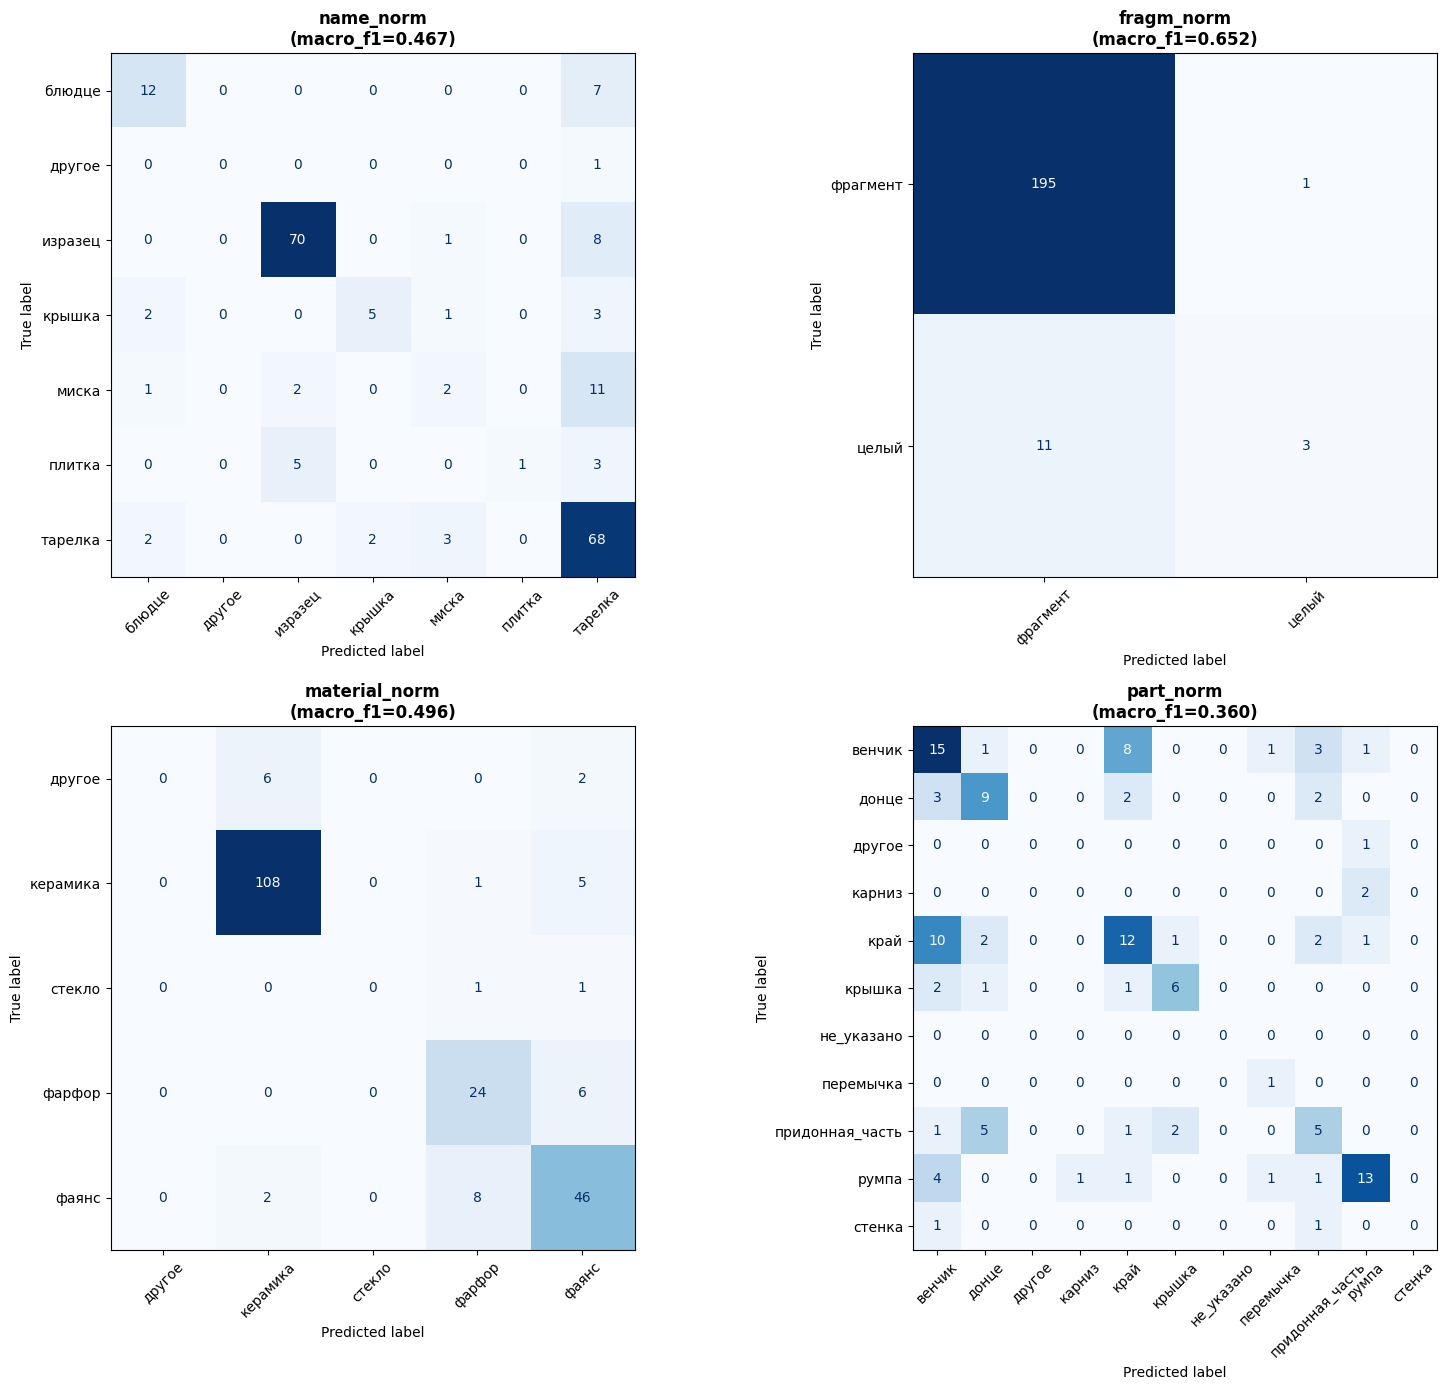

 Saved artifacts/figures/confusion_matrices.png


In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, f in enumerate(TARGET_FIELDS):
    m = val_masks[f]
    p, t = val_preds[f][m], val_targets[f][m]
    names = [label_decoders[f][i] for i in range(len(label_encoders[f]))]

    cm = confusion_matrix(t, p, labels=range(len(names)))
    disp = ConfusionMatrixDisplay(cm, display_labels=names)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False,
              xticks_rotation=45, values_format="d")
    axes[idx].set_title(f"{f}\n(macro_f1={field_summaries[f]['macro_f1']:.3f})",
                        fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("artifacts/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved artifacts/figures/confusion_matrices.png")


In [45]:
from sklearn.metrics import f1_score as f1_per_class_score

print("=" * 70)
print("TOP & BOTTOM CLASSES BY PER-CLASS F1")
print("=" * 70)

for f in TARGET_FIELDS:
    m = val_masks[f]
    p, t = val_preds[f][m], val_targets[f][m]
    names = [label_decoders[f][i] for i in range(len(label_encoders[f]))]

    per_class_f1 = f1_score(t, p, average=None, labels=range(len(names)), zero_division=0)
    support = [(t == i).sum() for i in range(len(names))]

    ranked = sorted(zip(names, per_class_f1, support),
                    key=lambda x: x[1], reverse=True)

    print(f"\n  {f} ({len(names)} classes):")
    print(f"  {'class':<25} {'F1':>6} {'support':>8}")
    print(f"  {'-'*42}")
    for name, f1_val, sup in ranked:
        bar = "█" * int(f1_val * 20)
        marker = " ← worst" if f1_val == ranked[-1][1] and f1_val < 0.3 else ""
        print(f"  {name:<25} {f1_val:>6.3f} {sup:>8}  {bar}{marker}")


TOP & BOTTOM CLASSES BY PER-CLASS F1

  name_norm (7 classes):
  class                         F1  support
  ------------------------------------------
  изразец                    0.897       79  █████████████████
  тарелка                    0.773       75  ███████████████
  блюдце                     0.667       19  █████████████
  крышка                     0.556       11  ███████████
  плитка                     0.200        9  ████
  миска                      0.174       16  ███
  другое                     0.000        1   ← worst

  fragm_norm (2 classes):
  class                         F1  support
  ------------------------------------------
  фрагмент                   0.970      196  ███████████████████
  целый                      0.333       14  ██████

  material_norm (5 classes):
  class                         F1  support
  ------------------------------------------
  керамика                   0.939      114  ██████████████████
  фаянс                      0.793     


  CONFIDENT ERRORS: name_norm


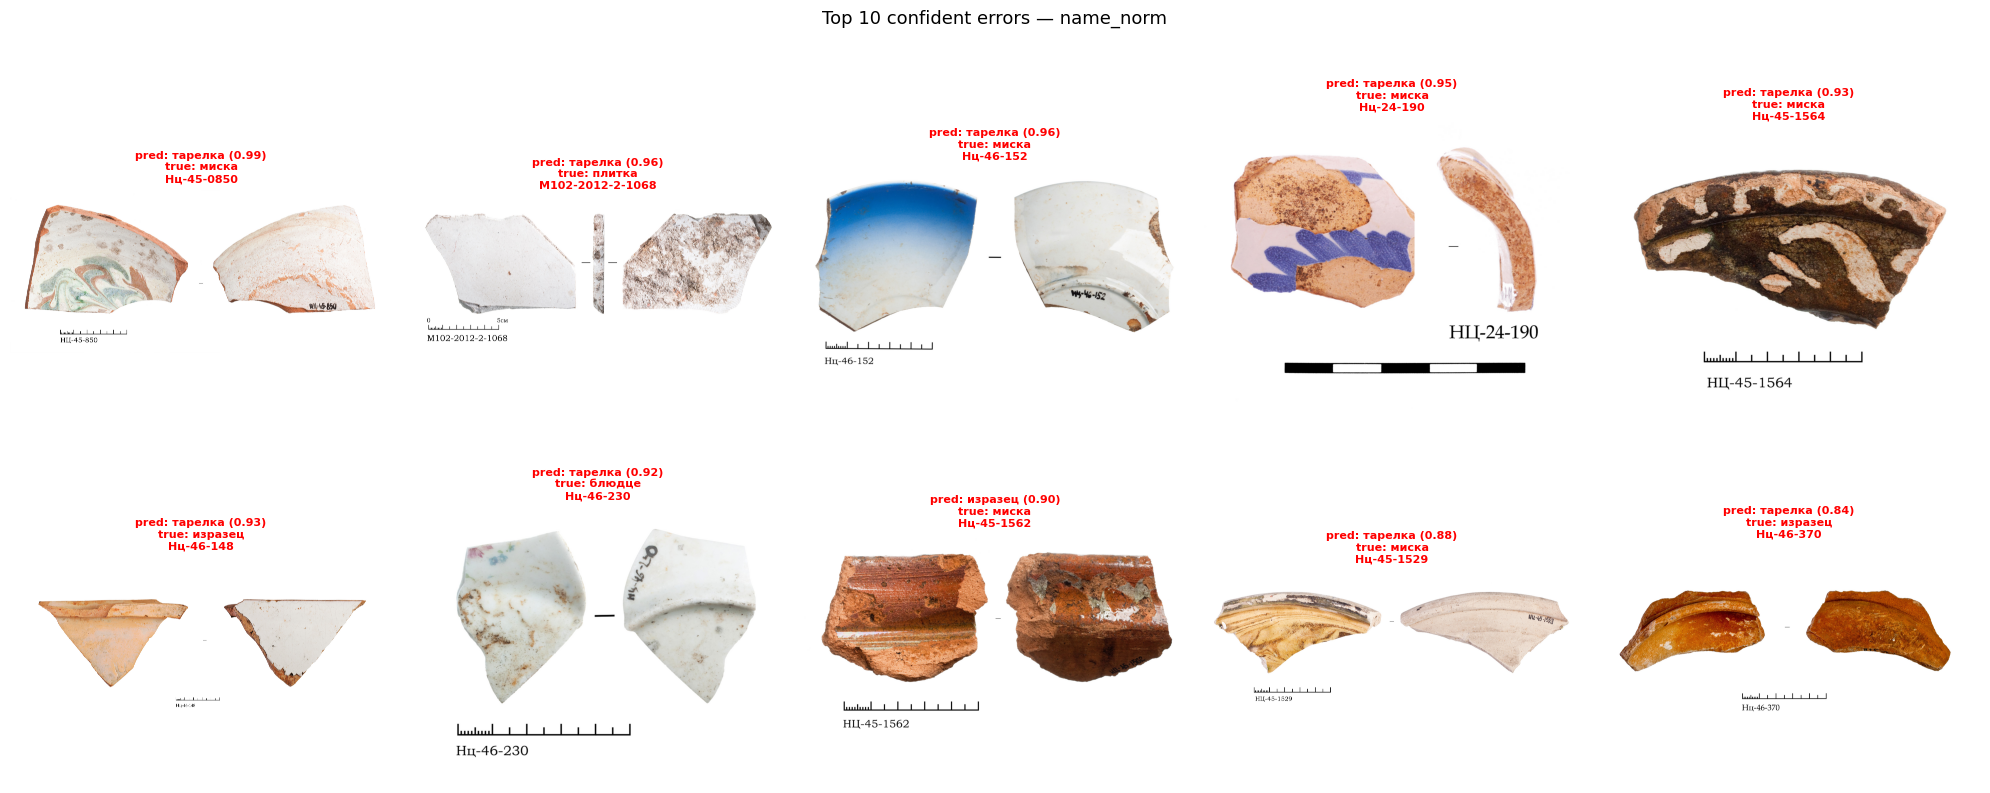


  CONFIDENT ERRORS: material_norm


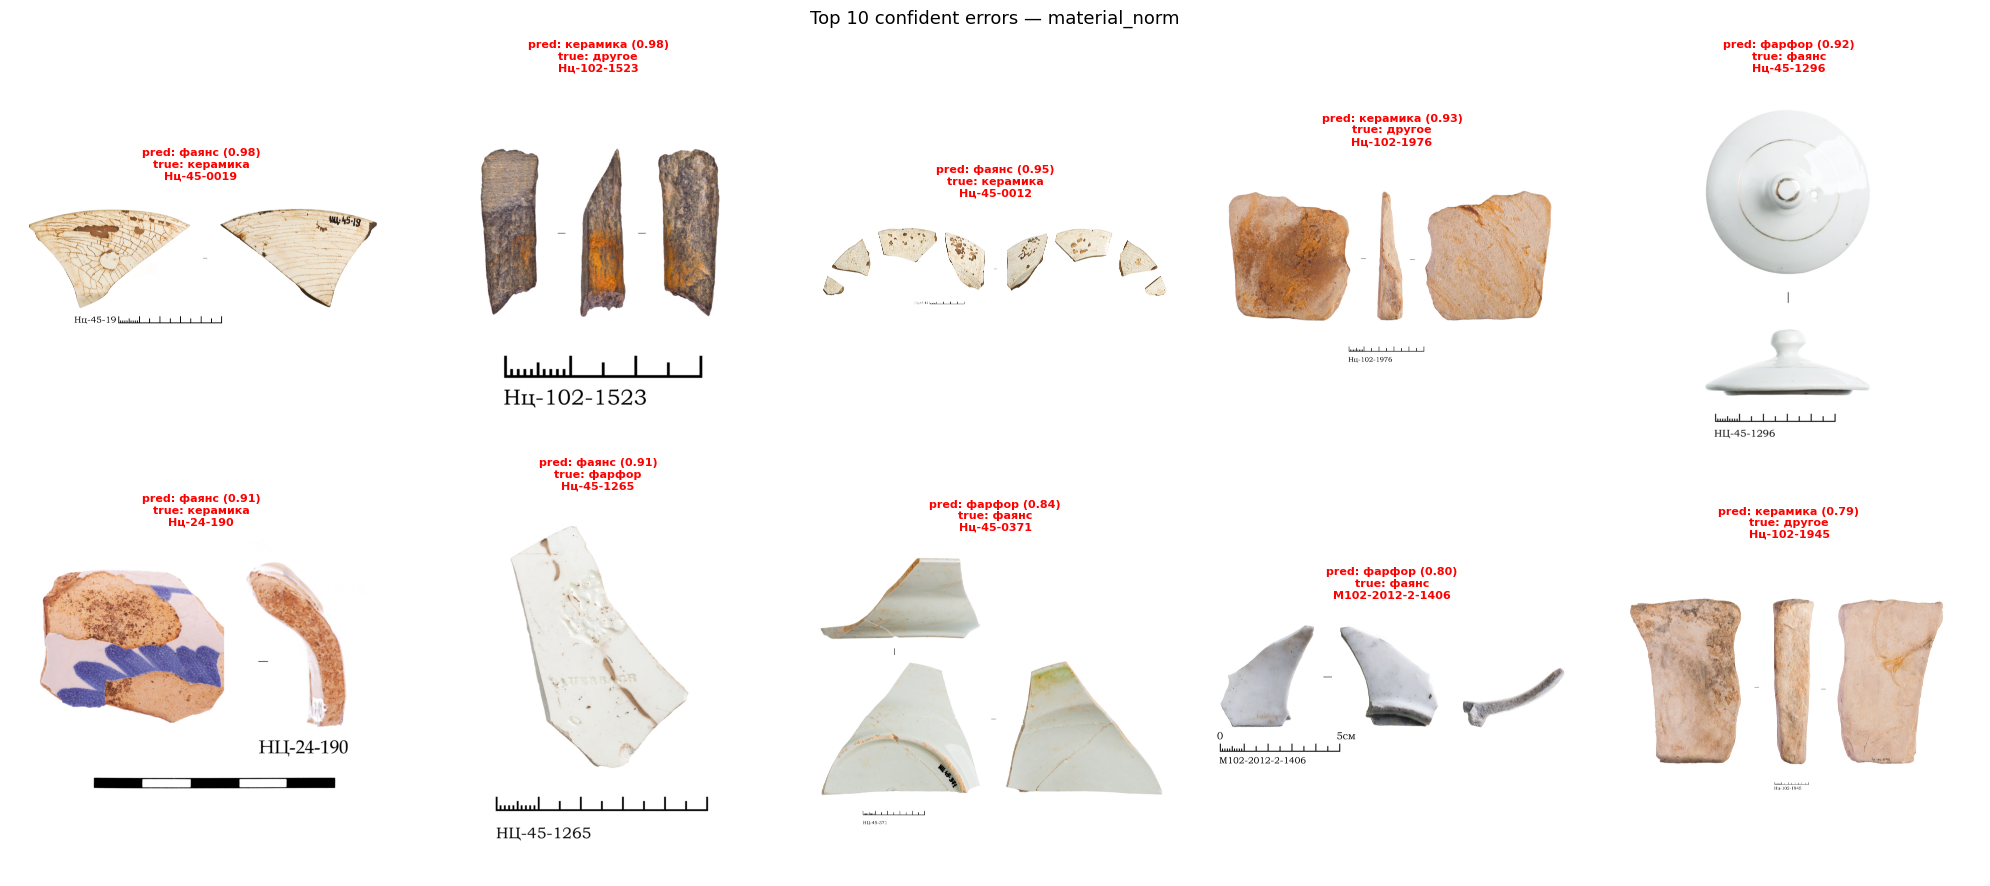

In [46]:
def show_errors(field: str, n: int = 10) -> None:
    """Show n worst errors for a field: wrong prediction + high confidence = bad."""
    m = val_masks[field]
    indices = np.where(m)[0]
    p = val_preds[field][indices]
    t = val_targets[field][indices]
    c = val_confs[field][indices]

    wrong = p != t
    wrong_indices = indices[wrong]
    wrong_conf = c[wrong]

    # Sort by confidence descending — most confident errors first
    order = np.argsort(-wrong_conf)
    top_n = order[:n]

    if len(top_n) == 0:
        print(f"  No errors for {field}!")
        return

    cols = min(5, len(top_n))
    rows = (len(top_n) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax_idx, sel in enumerate(top_n):
        real_idx = wrong_indices[sel]
        img_path = val_files[real_idx]
        code = val_codes[real_idx]

        pred_label = label_decoders[field][int(val_preds[field][real_idx])]
        true_label = label_decoders[field][int(val_targets[field][real_idx])]
        conf = val_confs[field][real_idx]

        try:
            img = Image.open(img_path).convert("RGB")
            axes[ax_idx].imshow(img)
        except Exception:
            axes[ax_idx].text(0.5, 0.5, "IMG ERR", ha="center", va="center")

        axes[ax_idx].set_title(
            f"pred: {pred_label} ({conf:.2f})\n"
            f"true: {true_label}\n"
            f"{code}",
            fontsize=8, color="red", fontweight="bold",
        )
        axes[ax_idx].axis("off")

    for j in range(len(top_n), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Top {len(top_n)} confident errors — {field}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/errors_{field}.png", dpi=100, bbox_inches="tight")
    plt.show()

# Show errors for two most interesting fields
for field in ["name_norm", "material_norm"]:
    print(f"\n{'='*50}")
    print(f"  CONFIDENT ERRORS: {field}")
    print(f"{'='*50}")
    show_errors(field, n=10)


In [47]:
run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    job_type="val_analysis", name="task13_val_analysis",
    config={"checkpoint": "best.pt", "epoch": ckpt["epoch"]},
    tags=["part2", "task13"],
)

wandb.log({"val/confusion_matrices": wandb.Image("artifacts/figures/confusion_matrices.png")})

for field in ["name_norm", "material_norm"]:
    path = f"artifacts/figures/errors_{field}.png"
    if os.path.exists(path):
        wandb.log({f"val/errors_{field}": wandb.Image(path)})

for f in TARGET_FIELDS:
    s = field_summaries[f]
    wandb.summary[f"val_best/acc_{f}"] = s["accuracy"]
    wandb.summary[f"val_best/macro_f1_{f}"] = s["macro_f1"]
wandb.summary["val_best/mean_macro_f1"] = mean_mf1

error_rows = []
for f in TARGET_FIELDS:
    m = val_masks[f]
    indices = np.where(m)[0]
    p = val_preds[f][indices]
    t = val_targets[f][indices]
    c = val_confs[f][indices]
    wrong = p != t
    for w_idx in indices[wrong]:
        error_rows.append([
            f.replace("_norm", ""),
            val_codes[w_idx],
            label_decoders[f][int(val_targets[f][w_idx])],
            label_decoders[f][int(val_preds[f][w_idx])],
            float(val_confs[f][w_idx]),
        ])

error_table = wandb.Table(
    columns=["field", "code", "true", "predicted", "confidence"],
    data=error_rows,
)
wandb.log({"val/error_table": error_table})

run.finish()
print(f" Analysis logged to W&B ({len(error_rows)} total errors across all fields)")


val_best/acc_fragm_norm,0.94286
val_best/acc_material_norm,0.84762
val_best/acc_name_norm,0.75238
val_best/acc_part_norm,0.49194
val_best/macro_f1_fragm_norm,0.65174
val_best/macro_f1_material_norm,0.49645
val_best/macro_f1_name_norm,0.46661
val_best/macro_f1_part_norm,0.35992
val_best/mean_macro_f1,0.49368


 Analysis logged to W&B (159 total errors across all fields)


## Ошибки на val

1. Близкие классы name (миска/тарелка/блюдце) на фрагментах.
2. material: фаянс/фарфор плохо различимы только по фото.
3. Редкие классы — мало примеров, F1 около нуля.


In [48]:
def classify_visual_mode(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        gray = np.mean(np.array(img), axis=2)
        fg_ratio = (gray <= 200).sum() / (w * h)
        if fg_ratio < 0.15:
            return "close-up"
        if fg_ratio > 0.6:
            return "single"
        return "multi-view"
    except Exception:
        return "unknown"

val_err = pd.DataFrame({"code": val_codes, "image_file": val_files})
for f in TARGET_FIELDS:
    m = val_masks[f]
    val_err.loc[m, f"err_{f}"] = val_preds[f][m] != val_targets[f][m]
err_cols = [c for c in val_err.columns if c.startswith("err_")]
val_err["any_err"] = val_err[err_cols].any(axis=1)
val_err["layout_mode"] = val_err["image_file"].map(classify_visual_mode)
print(pd.crosstab(val_err["layout_mode"], val_err["any_err"], margins=True))


any_err      False  True  All
layout_mode                  
close-up        30    43   73
multi-view      70    67  137
All            100   110  210


### Ошибки по layout_mode


## test_open


In [49]:
@torch.no_grad()
def collect_split_predictions(model, loader):
    model.eval()
    rows = []
    for imgs, tgts, msk, meta in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        bs = imgs.size(0)
        for i in range(bs):
            fields = {
                f: {
                    "label": decode_field(f, logits[f][i].argmax().item()),
                    "conf": float(torch.softmax(logits[f][i], dim=0).max().item()),
                }
                for f in TARGET_FIELDS
            }
            gt = {f: decode_field(f, tgts[f][i].item()) for f in TARGET_FIELDS}
            row = {
                "image_file": meta["image_file"][i],
                "code": meta["code"][i],
                "group_key": meta["group_key"][i],
                "auto_description": fields_to_auto_description(fields),
            }
            for f in TARGET_FIELDS:
                short = f.replace("_norm", "")
                row[f"pred_{short}"] = fields[f]["label"]
                row[f"confidence_{short}"] = fields[f]["conf"]
                row[f"gt_{short}"] = gt[f]
                row[f"mask_{short}"] = float(msk[f][i].item())
            rows.append(row)
    return pd.DataFrame(rows)


In [50]:
ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_df = collect_split_predictions(model, test_loader)
test_metrics = {}
for f in TARGET_FIELDS:
    m = test_df[f"mask_{f.replace('_norm', '')}"] > 0
    p = test_df.loc[m, f"pred_{f.replace('_norm', '')}"]
    t = test_df.loc[m, f"gt_{f.replace('_norm', '')}"]
    enc = label_encoders[f]
    p_idx = p.map(enc)
    t_idx = t.map(enc)
    test_metrics[f"acc_{f}"] = accuracy_score(t_idx, p_idx)
    test_metrics[f"macro_f1_{f}"] = f1_score(t_idx, p_idx, average="macro", zero_division=0)

test_metrics["mean_macro_f1"] = float(np.mean([test_metrics[f"macro_f1_{f}"] for f in TARGET_FIELDS]))

print("test_open metrics (best checkpoint)")
for f in TARGET_FIELDS:
    print(f"  {f}: acc={test_metrics[f'acc_{f}']:.3f}  macro_f1={test_metrics[f'macro_f1_{f}']:.3f}")
print(f"  mean macro_f1: {test_metrics['mean_macro_f1']:.3f}")

os.makedirs("artifacts/preds", exist_ok=True)
out_cols = ["image_file", "auto_description"] + [
    c for c in test_df.columns if c.startswith("pred_") or c.startswith("confidence_")
]
test_df[out_cols].to_csv("artifacts/preds/test_open_predictions.csv", index=False)
print("saved artifacts/preds/test_open_predictions.csv")


test_open metrics (best checkpoint)
  name_norm: acc=0.743  macro_f1=0.654
  fragm_norm: acc=0.929  macro_f1=0.813
  material_norm: acc=0.754  macro_f1=0.603
  part_norm: acc=0.731  macro_f1=0.460
  mean macro_f1: 0.632
saved artifacts/preds/test_open_predictions.csv


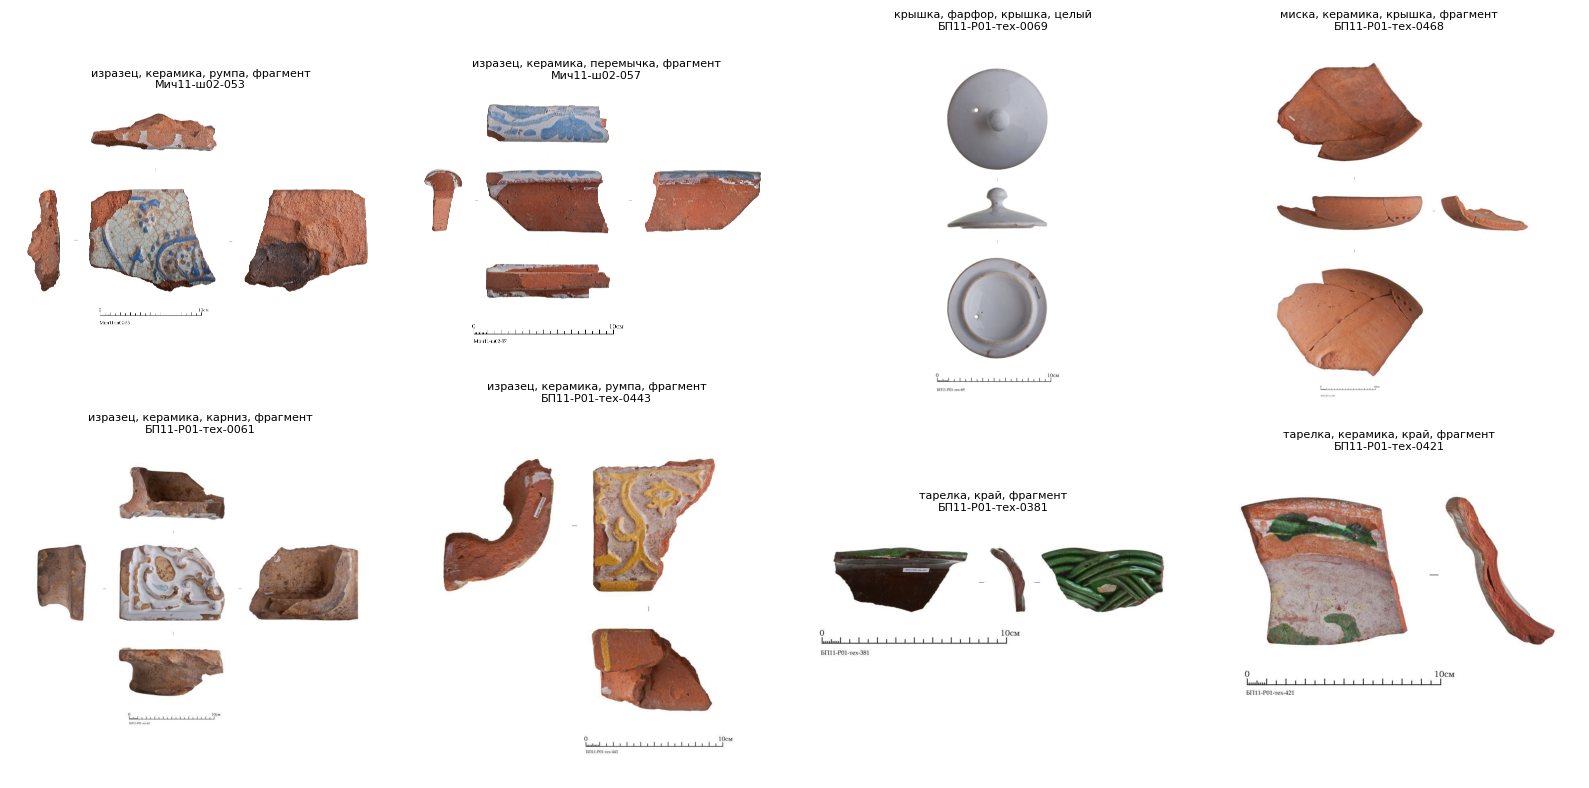

low confidence examples:
         code              auto_description
Кроп-2013-152       блюдце, фаянс, фрагмент
Кроп-2013-163         крышка, крышка, целый
Кроп-2013-392 крышка, фаянс, край, фрагмент


In [51]:
def show_prediction_examples(pred_df, n=8, sort_by_conf=False):
    df_show = pred_df.copy()
    if sort_by_conf:
        df_show["_min_conf"] = df_show[[c for c in df_show.columns if c.startswith("confidence_")]].min(axis=1)
        df_show = df_show.sort_values("_min_conf")
    sample = df_show.head(n)
    cols = min(4, len(sample))
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (_, r) in zip(axes, sample.iterrows()):
        try:
            ax.imshow(Image.open(r["image_file"]).convert("RGB"))
        except Exception:
            ax.text(0.5, 0.5, "no image", ha="center")
        ax.set_title(f"{r['auto_description']}\n{r['code']}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_prediction_examples(test_df, n=8)

low_conf = test_df[
    test_df[[c for c in test_df.columns if c.startswith("confidence_")]].min(axis=1) < 0.45
].head(3)
if len(low_conf):
    print("low confidence examples:")
    print(low_conf[["code", "auto_description"]].to_string(index=False))


good 5


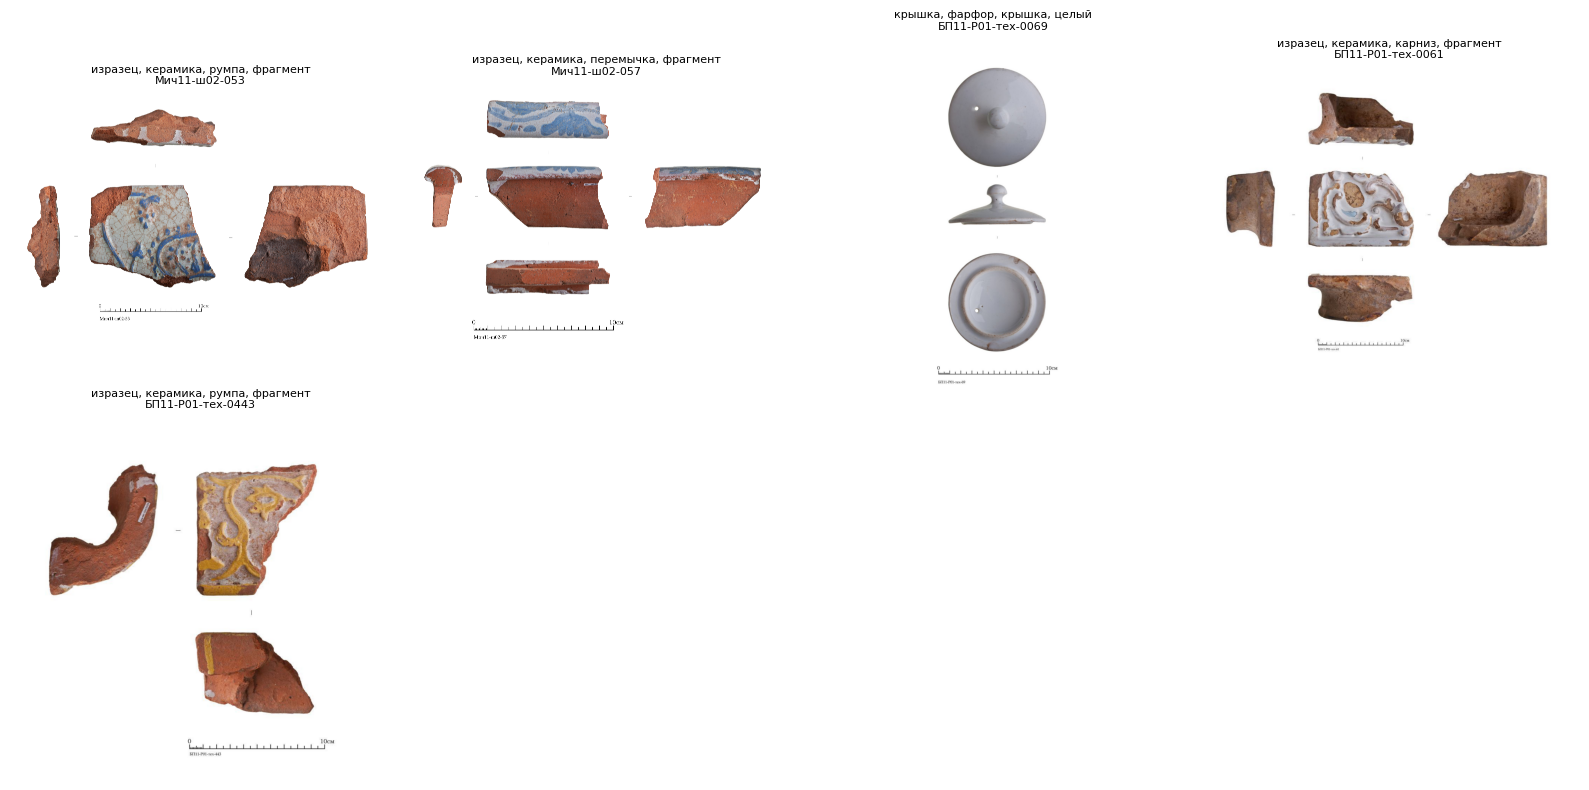

bad 5


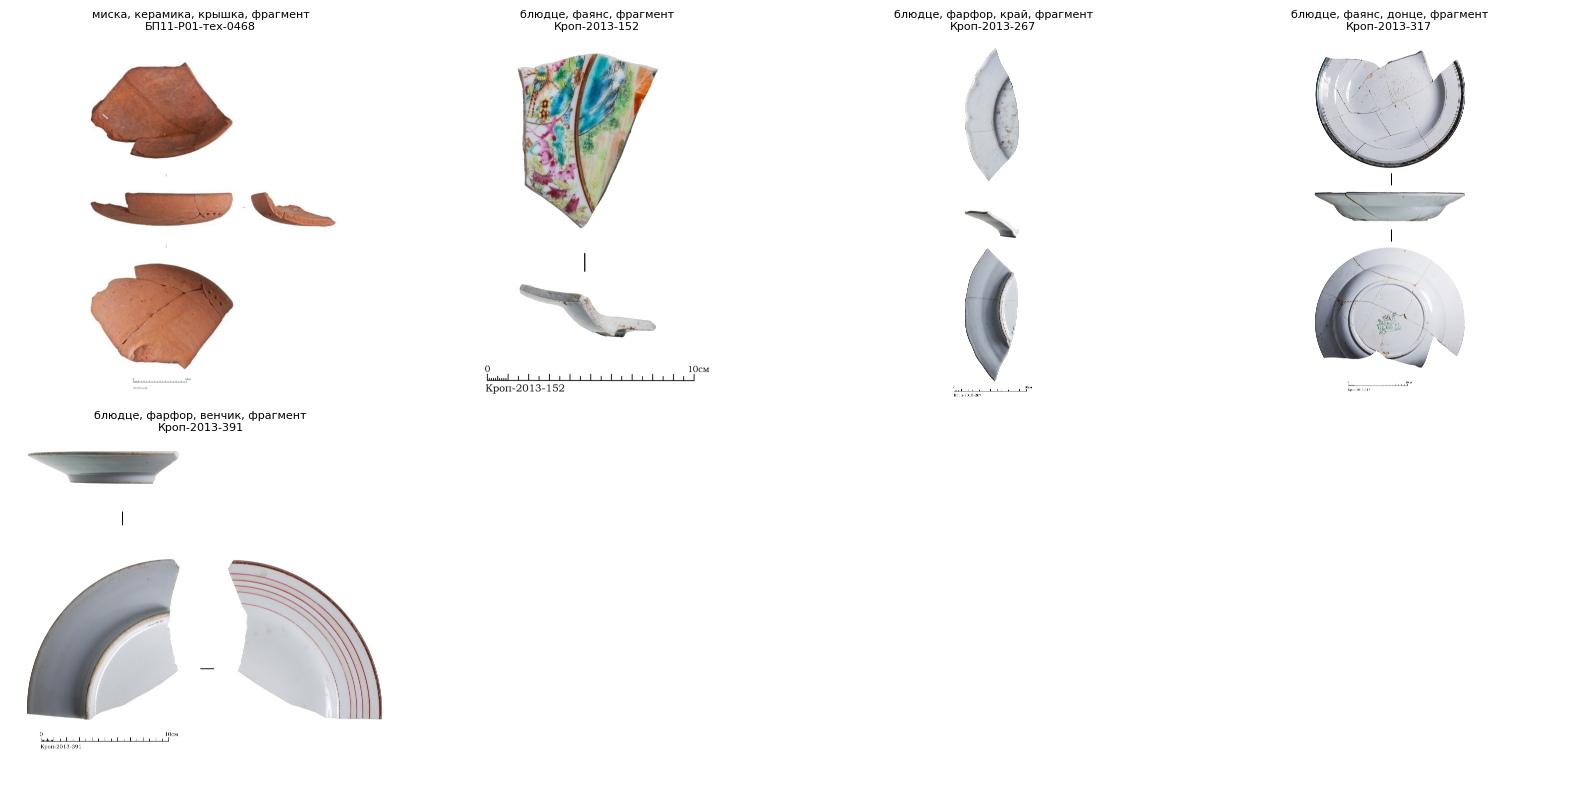

In [52]:
def show_labeled_examples(pred_df, n=5, field="name_norm"):
    short = field.replace("_norm", "")
    pred_df = pred_df.copy()
    pred_df["ok"] = pred_df[f"pred_{short}"] == pred_df[f"gt_{short}"]
    for title, part in [("good", pred_df[pred_df["ok"]].head(n)), ("bad", pred_df[~pred_df["ok"]].head(n))]:
        print(title, len(part))
        show_prediction_examples(part, n=min(n, len(part)))

show_labeled_examples(test_df, n=5, field="name_norm")


## Ablation

Запуск `run_ablation` опционален, если метрики уже в Drive. Итог — следующая ячейка.


In [53]:
import json
import time
import os
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts

ABL_DIR = "/content/drive/MyDrive/cu_data/similis_artifacts/ablation"
os.makedirs(ABL_DIR, exist_ok=True)
ABL_EPOCHS = 20

def run_ablation(
    exp_name: str,
    image_size: int = 384,
    pad_fill: int = 255,
    use_aug: bool = True,
    scheduler_type: str = "cosine",
    lr_backbone: float = 3e-5,
    lr_heads: float = 3e-4,
    weight_decay: float = 1e-4,
    n_epochs: int = ABL_EPOCHS,
    batch_size: int = 32,
    drop_rate: float = 0.1,
) -> dict:
    """Train one ablation experiment, save metrics to Drive, return best val metrics."""
    print(f"\n--- ablation: {exp_name} ---")
    print(f"  ABLATION: {exp_name}")
    print(f"  epochs={n_epochs}  image_size={image_size}  "
          f"scheduler={scheduler_type}  aug={use_aug}")


    # --- Transforms ---
    train_tf, eval_tf = build_transforms(image_size)
    if not use_aug:
        train_tf = eval_tf

    # --- DataLoaders ---
    abl_train_loader, abl_val_loader, _ = build_dataloaders(
        df, train_tf, eval_tf, batch_size=batch_size, num_workers=0
    )

    # --- Model (fresh from pretrained) ---
    abl_model = SIMILISMultiTask(
        n_classes=N_CLASSES, pretrained=True, drop_rate=drop_rate
    ).to(DEVICE)
    abl_model.freeze_backbone_stages(unfreeze_from_stage=3)

    # --- Optimizer ---
    optimizer = AdamW(
        abl_model.get_param_groups(lr_backbone, lr_heads, weight_decay)
    )

    # --- Scheduler ---
    if scheduler_type == "cosine":
        scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)
    elif scheduler_type == "warm_restarts":
        scheduler = CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=1, eta_min=1e-6
        )
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_type}")

    # --- Loss ---
    abl_train_crit = WeightedMaskedMultiTaskLoss(TARGET_FIELDS, class_weights).to(DEVICE)
    abl_val_crit = MaskedMultiTaskLoss(field_names=TARGET_FIELDS)

    # --- W&B (separate run per experiment) ---
    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        job_type="ablation", name=f"abl_{exp_name}",
        config={
            "exp_name": exp_name, "image_size": image_size,
            "scheduler": scheduler_type, "use_aug": use_aug,
            "lr_backbone": lr_backbone, "lr_heads": lr_heads,
            "n_epochs": n_epochs, "batch_size": batch_size,
            "drop_rate": drop_rate, "pad_fill": pad_fill,
        },
        tags=["part2", "task18", "ablation", exp_name],
        reinit=True,
    )

    # --- Training loop ---
    best_metric = 0.0
    best_metrics = None
    best_epoch = 0
    t_start = time.time()

    for epoch in range(n_epochs):
        t_ep = time.time()

        train_m = train_one_epoch(
            abl_model, abl_train_loader, abl_train_crit, optimizer, DEVICE
        )
        val_m = evaluate(abl_model, abl_val_loader, abl_val_crit, DEVICE)
        lr_now = optimizer.param_groups[0]["lr"]
        scheduler.step()

        dt = time.time() - t_ep
        log = {
            "epoch": epoch, "lr": lr_now, "epoch_time_s": dt,
            "train/loss": train_m["loss"], "val/loss": val_m["loss"],
            "val/mean_macro_f1": val_m["mean_macro_f1"],
        }
        for f in TARGET_FIELDS:
            log[f"train/acc_{f}"] = train_m[f"acc_{f}"]
            log[f"val/macro_f1_{f}"] = val_m[f"macro_f1_{f}"]
            log[f"val/acc_{f}"] = val_m[f"acc_{f}"]
        wandb.log(log, step=epoch)

        if val_m["mean_macro_f1"] > best_metric:
            best_metric = val_m["mean_macro_f1"]
            best_metrics = val_m.copy()
            best_epoch = epoch
            marker = " *"
        else:
            marker = ""

        eta_m = dt * (n_epochs - epoch - 1) / 60
        f1_str = " | ".join(
            f"{f.replace('_norm','')}" + "=" + f"{val_m[f'macro_f1_{f}']:.3f}"
            for f in TARGET_FIELDS
        )
        print(f"  ep {epoch:02d}/{n_epochs}  t_loss={train_m['loss']:.3f}  "
              f"v_mF1={val_m['mean_macro_f1']:.3f}  [{f1_str}]  "
              f"lr={lr_now:.1e}  {dt:.0f}s  ETA {eta_m:.0f}m{marker}")

    elapsed = (time.time() - t_start) / 60

    # --- W&B summary ---
    wandb.summary["best_val_mean_macro_f1"] = best_metric
    wandb.summary["best_epoch"] = best_epoch
    wandb.summary["train_time_min"] = elapsed
    run.finish()

    # --- Save metrics to Drive ---
    save_data = {
        k: float(v) for k, v in best_metrics.items()
        if isinstance(v, (int, float, np.floating))
    }
    save_data["exp_name"] = exp_name
    save_data["best_epoch"] = best_epoch
    save_data["train_time_min"] = round(elapsed, 1)
    metrics_path = f"{ABL_DIR}/{exp_name}_metrics.json"
    with open(metrics_path, "w") as f_out:
        json.dump(save_data, f_out, indent=2)

    print(f"\n   {exp_name} done in {elapsed:.1f} min")
    print(f"   Best epoch: {best_epoch}, v_mF1={best_metric:.4f}")
    print(f"   Metrics saved: {metrics_path}")

    # --- Compare with baseline ---
    compare_with_baseline(best_metrics, exp_name=exp_name)

    # Free GPU memory
    del abl_model, optimizer, scheduler
    torch.cuda.empty_cache()

    return best_metrics

print(" run_ablation defined")


 run_ablation defined


In [54]:
# Experiment 1: Warm Restarts scheduler
metrics_warmrestart = run_ablation(
    exp_name="warm_restarts",
    scheduler_type="warm_restarts",
)

# Experiment 2: Resolution 224
metrics_res224 = run_ablation(
    exp_name="res224",
    image_size=224,
)

# Experiment 3: No augmentations
metrics_noaug = run_ablation(
    exp_name="no_aug",
    use_aug=False,
)

print("\n\n" + "=" * 65)
print("  ALL ABLATION EXPERIMENTS COMPLETE")
print("=" * 65)



--- ablation: warm_restarts ---
  ABLATION: warm_restarts
  epochs=20  image_size=384  scheduler=warm_restarts  aug=True
 train:  774 samples,  24 batches
 val:    210 samples,   7 batches
 test:   183 samples,   6 batches


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


KeyboardInterrupt: 

Так же видим, что ablation работает, ячейка запускалась до этого, скрины вандб ниже и в артефактах

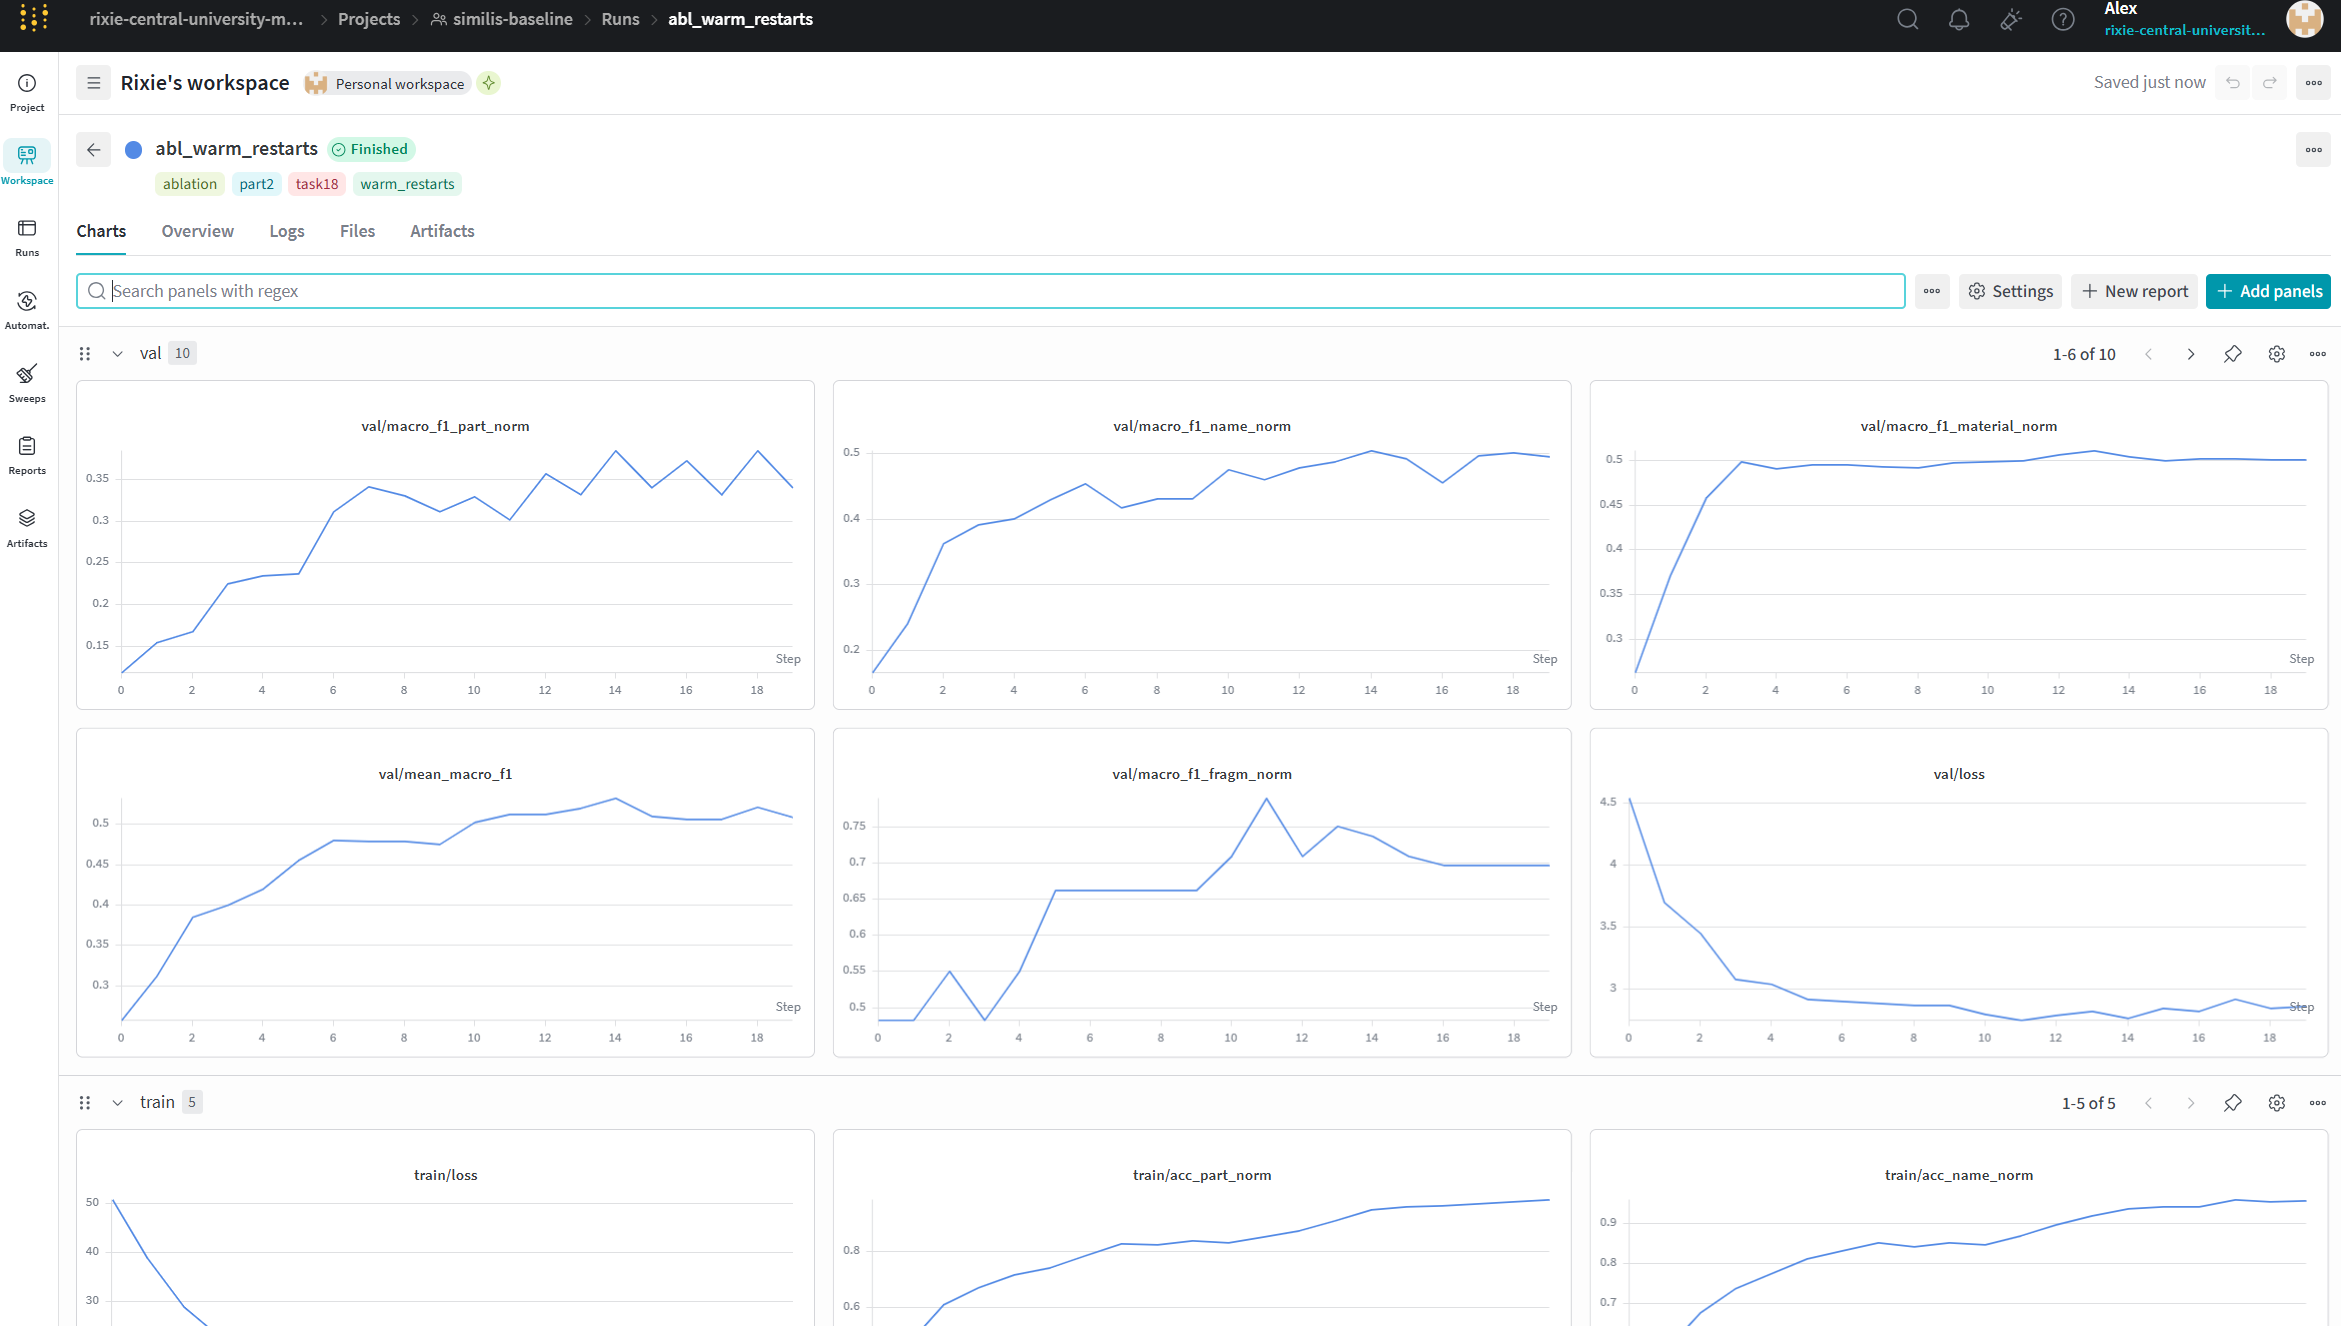

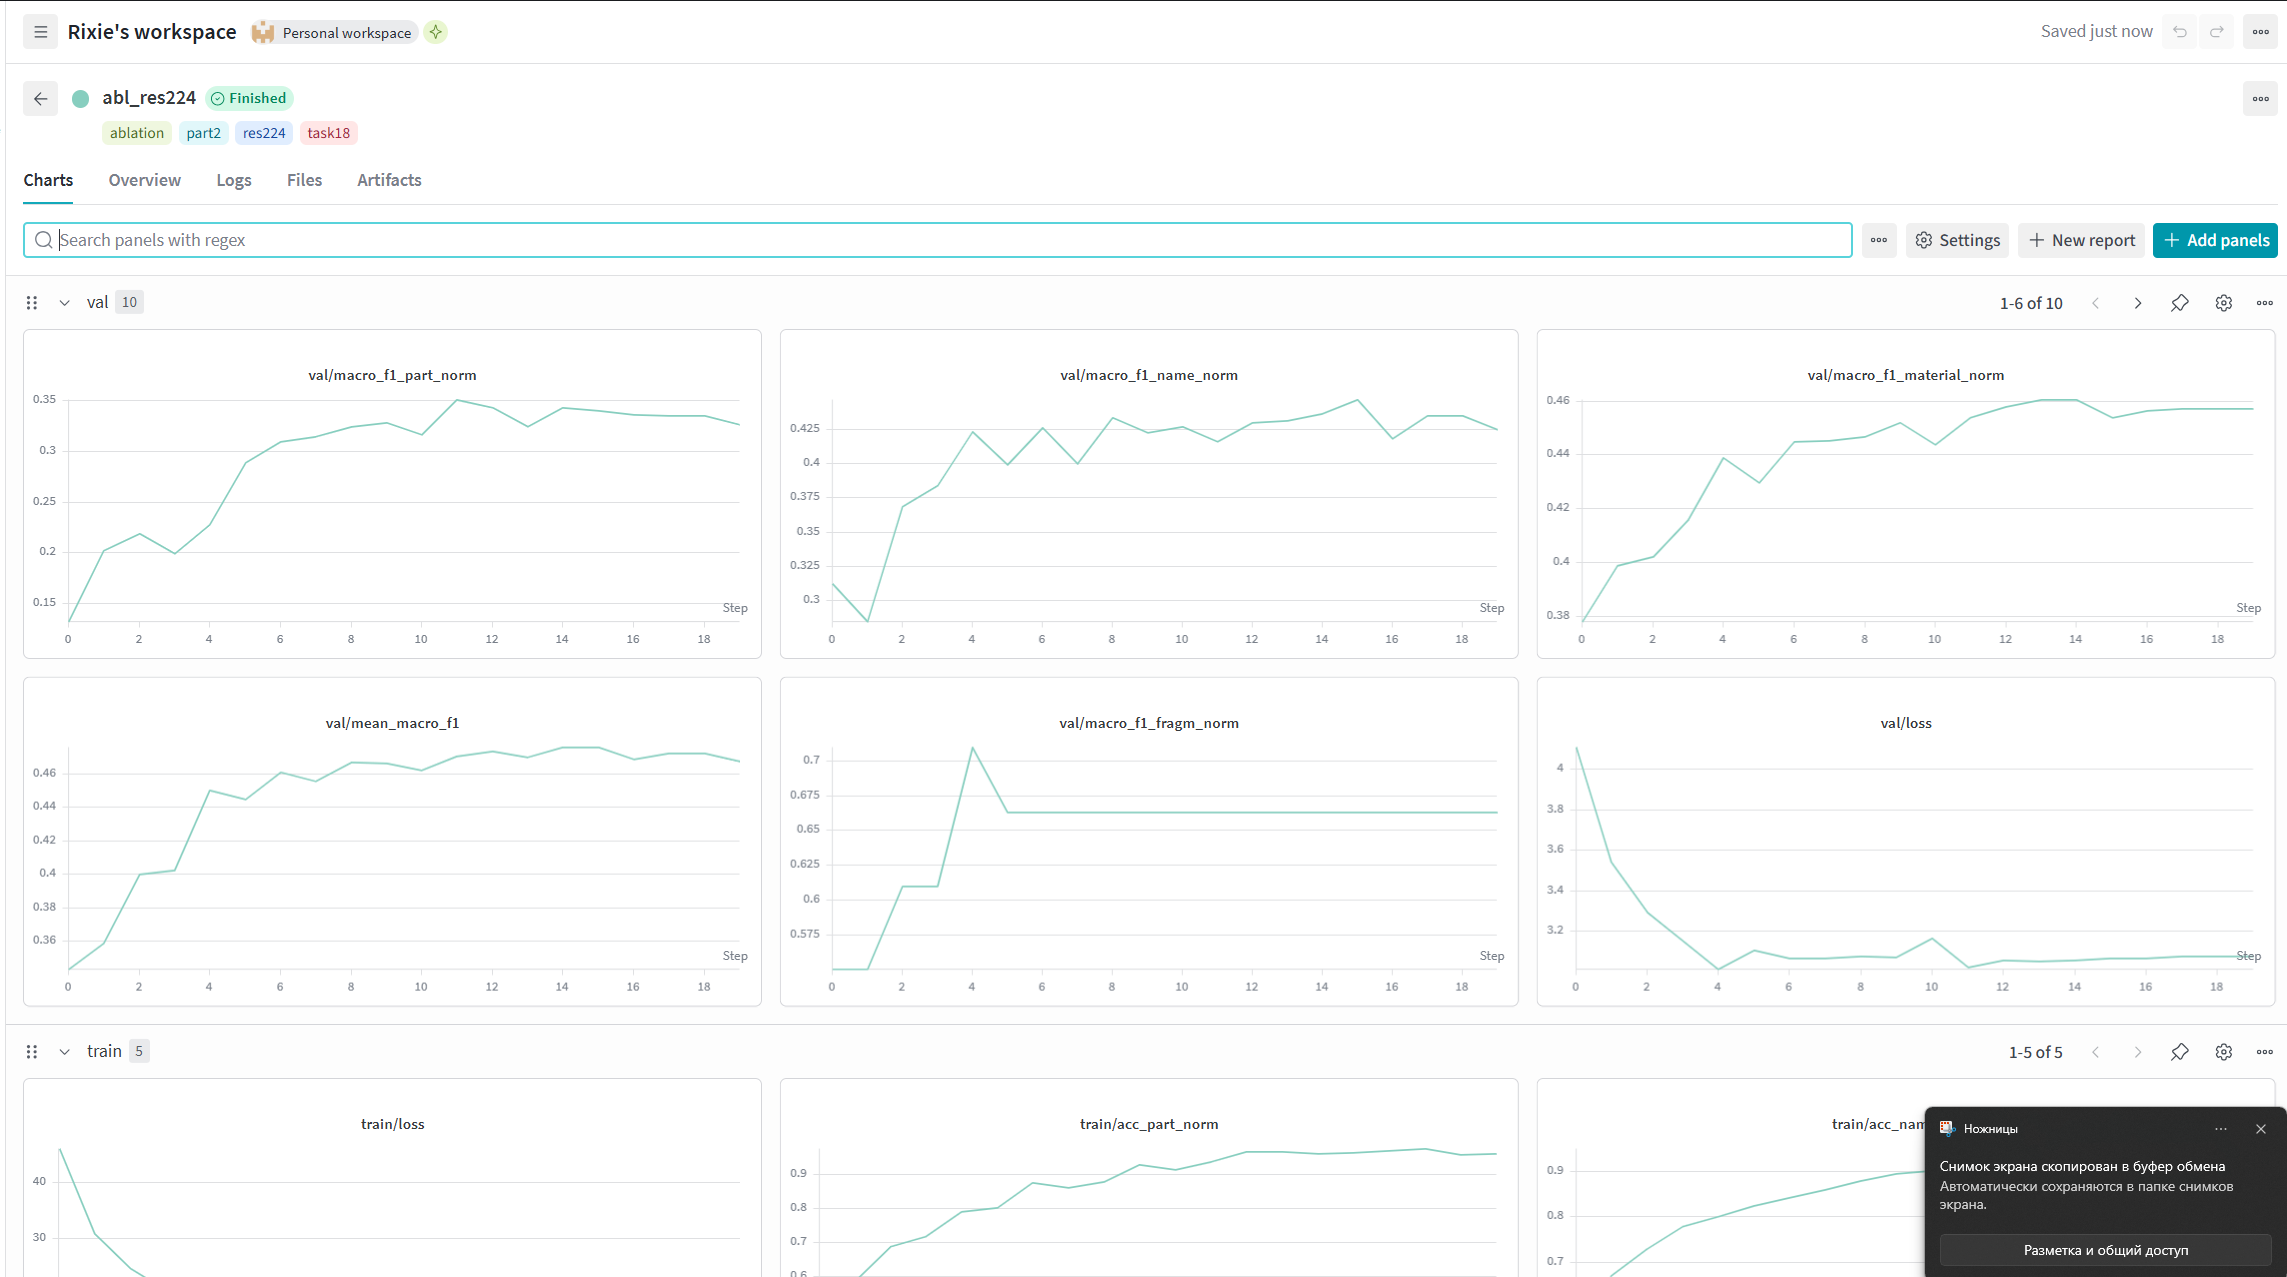

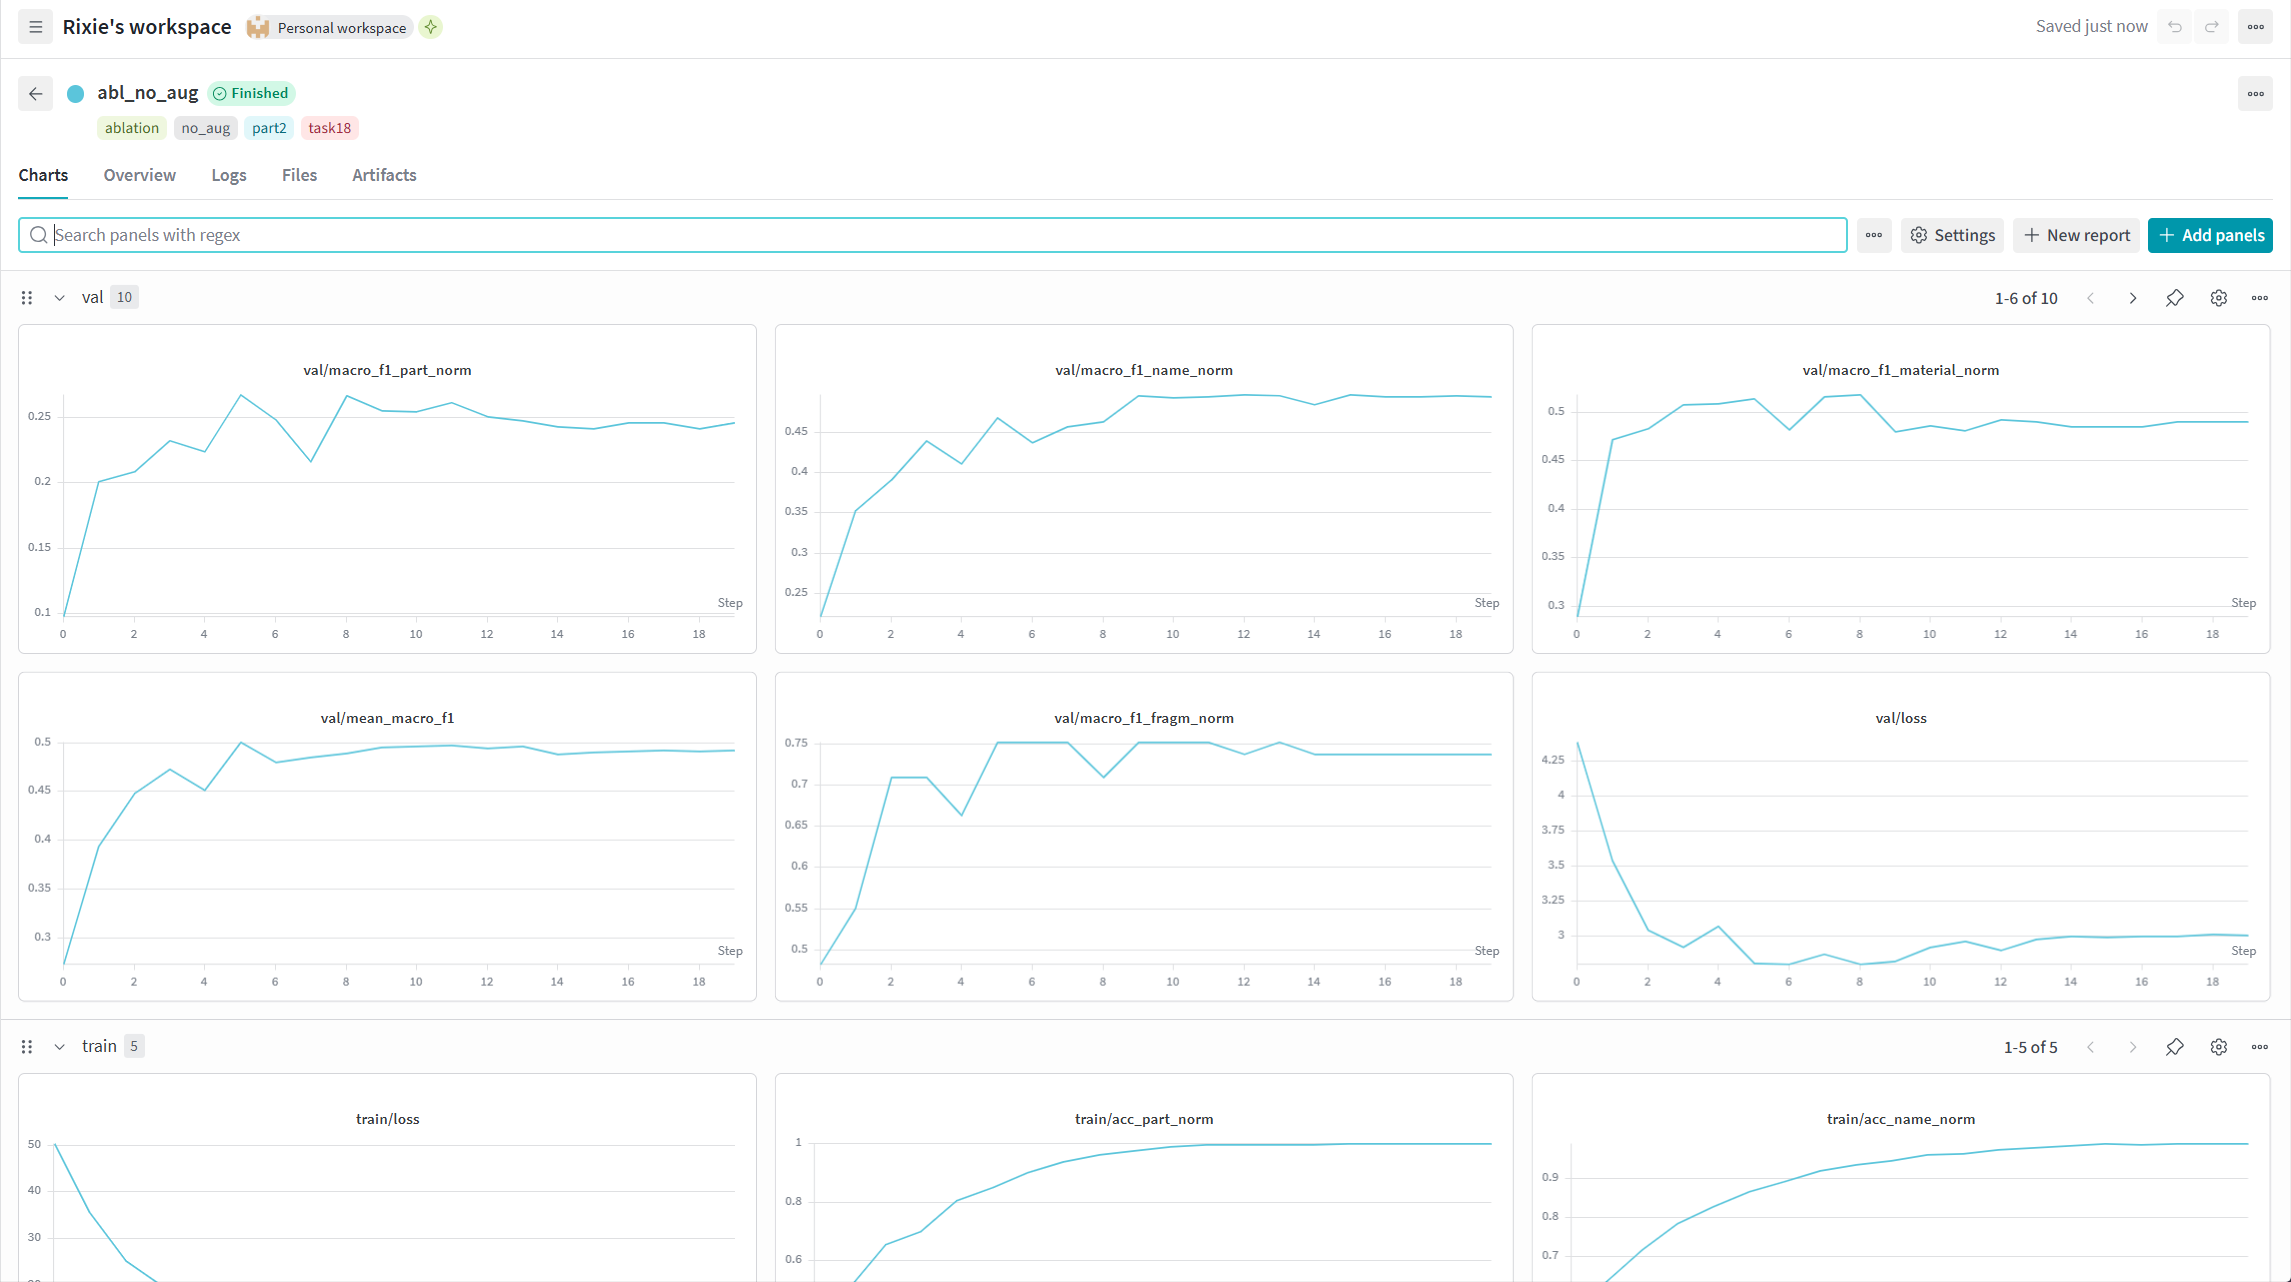

In [ ]:
import json
import os

if 'ABL_DIR' not in globals():
    ABL_DIR = "/content/drive/MyDrive/cu_data/similis_artifacts/ablation"


metrics_file = f"{ABL_DIR}/warm_restarts_metrics.json"

if os.path.exists(metrics_file):
    with open(metrics_file) as f:
        metrics_warmrestart = json.load(f)
    print(f" warm_restarts loaded from Drive: v_mF1={metrics_warmrestart['mean_macro_f1']:.4f}")
else:
    print(f"! {metrics_file} not found. Re-running experiment 1...")
    metrics_warmrestart = run_ablation(
        exp_name="warm_restarts",
        scheduler_type="warm_restarts",
    )

metrics_res224 = run_ablation(
    exp_name="res224",
    image_size=224,
)

metrics_noaug = run_ablation(
    exp_name="no_aug",
    use_aug=False,
)

print("\n" + "=" * 65)
print("  ALL ABLATION EXPERIMENTS COMPLETE")
print("=" * 65)


In [55]:
# Загрузка метрик с гугл диска
with open(f"{ABL_DIR}/warm_restarts_metrics.json") as f:
    metrics_warmrestart = json.load(f)
print(f" warm_restarts loaded: v_mF1={metrics_warmrestart['mean_macro_f1']:.4f}")

with open(f"{ABL_DIR}/res224_metrics.json") as f:
    metrics_res224 = json.load(f)
print(f" res224 loaded: v_mF1={metrics_res224['mean_macro_f1']:.4f}")


with open(f"{ABL_DIR}/no_aug_metrics.json") as f:
    metrics_noaug = json.load(f)
print(f" no_aug loaded: v_mF1={metrics_noaug['mean_macro_f1']:.4f}")

print("\n" + "=" * 65)
print("  ALL ABLATION EXPERIMENTS COMPLETE")
print("=" * 65)


 warm_restarts loaded: v_mF1=0.5325
 res224 loaded: v_mF1=0.4761
 no_aug loaded: v_mF1=0.5006

  ALL ABLATION EXPERIMENTS COMPLETE


In [56]:
baseline_m = get_baseline_metrics()

# If any experiment was lost (Colab crash), reload from Drive
all_runs = {"baseline": baseline_m}
for name, mem_metrics in [("warm_restarts", metrics_warmrestart),
                           ("res224", metrics_res224),
                           ("no_aug", metrics_noaug)]:
    if mem_metrics is not None:
        all_runs[name] = mem_metrics
    else:
        fallback = f"{ABL_DIR}/{name}_metrics.json"
        if os.path.exists(fallback):
            with open(fallback) as f_in:
                all_runs[name] = json.load(f_in)
            print(f"  ! {name}: loaded from Drive fallback")

rows = []
for run_name, m in all_runs.items():
    row = {"experiment": run_name}
    for f in TARGET_FIELDS:
        key = f"macro_f1_{f}"
        row[f.replace("_norm", "")] = m.get(key, 0.0)
    row["mean_mF1"] = m.get("mean_macro_f1", 0.0)
    row["val_loss"] = m.get("loss", 0.0)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("experiment")

bl = summary_df.loc["baseline"]
delta_df = summary_df.subtract(bl).drop("baseline")
delta_df.index = [f"d_{name}" for name in delta_df.index]

print("\n" + "=" * 80)
print("ABLATION STUDY — RESULTS (20 epochs each)")
print("=" * 80)
print(summary_df.round(3).to_string())
print(f"\n{'-'*80}")
print("DELTAS vs BASELINE:")
print(delta_df.round(3).to_string())
print("=" * 80)

best_exp = summary_df["mean_mF1"].idxmax()
print(f"\n  Best experiment: {best_exp} "
      f"(mean_mF1 = {summary_df.loc[best_exp, 'mean_mF1']:.4f})")

# Save CSV
os.makedirs("artifacts/reports", exist_ok=True)
full_table = pd.concat([summary_df, delta_df])
full_table.round(4).to_csv("artifacts/reports/ablation_summary.csv")
print(f"   Saved artifacts/reports/ablation_summary.csv")

# --- W&B summary run ---
run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    job_type="ablation_summary", name="task18_summary",
    tags=["part2", "task18"],
    reinit=True,
)
wandb.log({
    "ablation/summary": wandb.Table(
        dataframe=summary_df.reset_index().round(4)
    ),
    "ablation/deltas": wandb.Table(
        dataframe=delta_df.reset_index().round(4)
    ),
})
wandb.summary["best_experiment"] = best_exp
wandb.summary["best_mean_mF1"] = float(summary_df.loc[best_exp, "mean_mF1"])
run.finish()
print("   Summary logged to W&B")


 Baseline loaded from epoch 14, mean_macro_f1=0.4937

ABLATION STUDY — RESULTS (20 epochs each)
                name  fragm  material   part  mean_mF1  val_loss
experiment                                                      
baseline       0.467  0.652     0.496  0.360     0.494     2.803
warm_restarts  0.505  0.738     0.504  0.384     0.532     2.761
res224         0.447  0.663     0.454  0.341     0.476     3.067
no_aug         0.468  0.752     0.515  0.268     0.501     2.811

--------------------------------------------------------------------------------
DELTAS vs BASELINE:
                  name  fragm  material   part  mean_mF1  val_loss
d_warm_restarts  0.038  0.086     0.007  0.024     0.039    -0.042
d_res224        -0.019  0.011    -0.042 -0.019    -0.018     0.264
d_no_aug         0.002  0.100     0.018 -0.092     0.007     0.008

  Best experiment: warm_restarts (mean_mF1 = 0.5325)
   Saved artifacts/reports/ablation_summary.csv


best_experiment,warm_restarts
best_mean_mF1,0.53247


   Summary logged to W&B


## Задание 21. Итоговый чек-лист и выводы

| Параметр | Значение |
|----------|----------|
| Поля | name_norm, material_norm, part_norm, fragm_norm |
| group_key | префикс code до последнего `-` |
| backbone | convnext_tiny.fb_in22k_ft_in1k |
| image_size | 384, resize longest side + pad |
| аугментации | flip, rotation 10, ColorJitter (без hue) |
| optimizer | AdamW, lr backbone 3e-5, heads 3e-4 |
| scheduler | CosineAnnealingLR |
| best val mean macro-F1 | см. ячейку обучения / W&B |
| test_open mean macro-F1 | см. ячейку test_open |


### Что было сделано

В проекте реализован baseline-пайплайн для задачи SIMILIS: изображение археологического артефакта преобразуется в набор нормализованных атрибутов, после чего из них собирается формализованное поле `auto_description`.

В качестве целевых полей были выбраны четыре признака:

- `name_norm` — тип предмета;
- `material_norm` — материал;
- `part_norm` — часть или зона предмета;
- `fragm_norm` — степень целостности.

Другие признаки часто зависят не только от изображения, но и от экспертного контекста, поэтому для честного baseline их лучше не предсказывать напрямую.

### Данные и подготовка корпуса

Исходные таблицы были объединены и сопоставлены с изображениями. После фильтрации строк без изображения и удаления явно проблемных силуэтных масок в рабочем корпусе осталось **1167 изображений**. Это именно тот корпус, на котором дальше строился split, нормализация словарей и обучение модели.

В данных была обнаружена неоднородность как по изображениям, так и по текстовым описаниям. Описания полуформализованные: встречаются сокращения, синонимы, разный порядок слов, неопределенные формулировки вида `(?)`, а также разная степень детализации. Поэтому перед обучением были построены нормализованные словари, а исходные значения сохранены как `raw`-поля для последующего анализа ошибок.

Для предотвращения утечки был введен `group_key`: из кода предмета удалялась последняя числовая часть, чтобы близкие предметы одной серии или одного контекста не попадали одновременно в train и val/test. Всего получилось **72 группы**. Split был сделан на уровне групп, а не отдельных строк.

Финальный split:

- train: около **66.3%**;
- val: около **18.0%**;
- test_open: около **15.7%**.

### Нормализация целевых полей

Для `name_norm` было оставлено 7 классов. Основные классы: `тарелка`, `изразец`, `блюдце`, `крышка`, `миска`. Редкие и нерелевантные для baseline типы были сведены в `другое`.

Для `material_norm` было оставлено 5 классов: `керамика`, `фаянс`, `фарфор`, `стекло`, `другое`. Разные виды глины и керамики были сведены в общий класс `керамика`, потому что на изображении тонкое различение сырья часто ненадежно. Классы `стекло` и `другое` остались редкими, поэтому по ним ожидаемо хуже macro-F1.

Для `fragm_norm` 2 класса: `фрагмент` и `целый`.

Для `part_norm` было оставлено 11 классов. При этом у 511 объектов часть предмета не была явно извлечена из описания, поэтому для таких строк используется `part_is_missing` и маска в loss/metrics. Это важно: модель не должна обучаться на искусственно подставленной метке, если в исходном описании часть предмета фактически не указана.

### EDA изображений и preprocessing

EDA показал, что корпус неоднороден по визуальному режиму:

- есть карточки с несколькими ракурсами или несколькими фрагментами одного предмета;
- есть close-up клейм, надписей и донец;
- есть одиночные фрагменты на светлом фоне;
- часто встречаются служебные элементы: масштабная линейка, подписи, инвентарные номера;
- сильно варьируются размеры изображений, соотношение сторон и доля предмета в кадре.

Аугментации были выбраны умеренные: горизонтальный flip, небольшой rotation и слабый ColorJitter без изменения hue. Сильные цветовые искажения не использовались, потому что цвет поверхности, полива, нагар и материал могут быть полезными признаками.

### Модель и обучение

В качестве baseline использовалась multi-task модель:

- backbone: `convnext_tiny.fb_in22k_ft_in1k`;
- общий визуальный эмбеддинг;
- отдельная classification head для каждого поля;
- loss: masked multi-task CrossEntropy;
- optimizer: AdamW;
- scheduler: CosineAnnealingLR;
- image size: 384;
- checkpoint: `best.pt` по mean macro-F1 на val.

Такой подход удобен для baseline, потому что все поля обучаются на общем визуальном представлении, но каждое поле имеет собственную голову и собственную метрику. Это лучше контролируется, чем генерация описания напрямую текстовой моделью.

Перед основным обучением был сделан tiny-overfit test, чтобы проверить, что Dataset, DataLoader, loss, masks и heads связаны корректно. После этого была проведена основная тренировка и оценка на val.

### Метрики и качество

Лучшая val-метрика baseline составила примерно:

- **macro-F1: 0.4937**

По отдельным полям видно, что модель лучше справляется с частыми и визуально выраженными классами, чем с редкими или неоднозначными.

Главный вывод по метрикам: baseline действительно учится и дает осмысленные предсказания, но задача не сводится к простой классификации. Ограничения связаны не только с архитектурой, но и с дисбалансом классов неполной визуальной наблюдаемостью некоторых признаков и недостатком данных.

### Шаблон auto_description

Итоговое описание собирается не свободной генерацией, а контролируемым шаблоном. Это сделано специально: для каталожного описания важнее стабильность, воспроизводимость и отсутствие галлюцинаций, чем красивый естественный текст.

Поля включаются в `auto_description` с учетом confidence threshold:

- `name_norm` является основным полем; при низкой уверенности используется более общий fallback;
- `material_norm` добавляется только при достаточной уверенности и не добавляется для слишком общего класса `другое`;
- `part_norm` добавляется только если поле не пропущено и модель достаточно уверена;
- `fragm_norm` добавляется как признак целостности, если уверенность выше порога.

Такой подход позволяет модели вести себя осторожно: лучше пропустить сомнительное уточнение, чем уверенно добавить неверный материал или часть предмета.

### Основные ошибки

Основные ошибки связаны с несколькими группами факторов.

1. Визуально близкие классы.  
   `тарелка`, `блюдце`, `миска` и другие сосудные формы часто представлены только фрагментом. Без полного профиля предмета их трудно различать даже экспертно.

2. Материал не всегда надежно виден по фото.  
   Различение `фаянс` / `фарфор` / `керамика` иногда требует физических свойств, контекста или экспертного знания. На изображении это часто проявляется только косвенно через цвет, поливу и фактуру.

3. Редкие классы.  
   Классы `стекло`, `другое`, `карниз`, `стенка`, `перемычка` представлены малым числом примеров. Поэтому они почти не влияют на accuracy, но сильно снижают macro-F1.

5. Неполная разметка части предмета.  
   У значительной части объектов `part_norm` не указан. Для таких случаев используется mask, иначе модель обучалась бы на фиктивной метке.

### Ablation study

Для проверки устойчивости baseline были запланированы и частично проведены сравнения:

- базовый конфиг 384 px;
- уменьшение разрешения до 224 px;
- отключение train-аугментаций;
- альтернативный scheduler с warm restarts.

Эти сравнения полезны, потому что в SIMILIS качество зависит не только от backbone, но и от preprocessing. Особенно важно проверять разрешение и аугментации: мелкие клейма, края, донца и орнаменты могут теряться при низком разрешении или агрессивной обработке.

Финальный выбор конфигурации должен делаться по одному и тому же `val_inner`, без использования `test_open` для подбора гиперпараметров.